# Projet Analyse et Visualisation des Données

## Introduction
Ce projet vise à analyser et visualiser un ensemble de données afin d'extraire des insights significatifs. Nous utiliserons des techniques d'analyse de données et de visualisation pour mieux comprendre les tendances et les patterns présents dans les données.

# TripSky — Optimisation des ventes et comportements clients


# Contexte
TripSky est une entreprise française qui propose des voyages insolites autour de l’aventure, avec sensations fortes garanties, de la détente et de la culture. TripSky a pour objectif final d’améliorer les ventes sur l’année fiscale en cours. Pour cela vous allez collaborer avec June, la directrice marketing, pour analyser le comportement d'achat des clients. Elle vous fournira les données nécessaires à la préparation et à l’analyse des résultats. Au total, vous allez devoir travailler à partir de 2 bases de données en format .csv :

* Données clients TripSky
* Données entreprise TripSky

# Phase 1 : Contexte et Problème Métier

## But :
Question centrale actionnable : Quels profils clients sont les plus rentables pour TripSky, et quels leviers (type de voyage, saison, destination, mode de paiement, budget annuel) permettent d'augmenter le revenu moyen par client ?

Observations initiales :
- Les deux jeux de données couvrent les clients et l'activité commerciale journalière de TripSky.
- Les variables clients incluent le type de voyage, la destination, la saison, le budget annuel, le prix total et le mode de paiement.
- Les données entreprise fournissent le nombre de clients, le revenu des ventes, les dépenses publicitaires et le nombre de réservations par date.

Sous-questions :
1. Quels segments de clients génèrent le meilleur revenu moyen par voyage ?
2. Quelles saisons et destinations maximisent les prix totaux ?
3. Quels modes de paiement sont associés aux plus fortes dépenses ?
4. Existe-t-il des profils de clients avec un budget de voyage annuel élevé mais un faible prix total moyen ?
5. Comment relier les volumes de réservation et le revenu des ventes aux campagnes publicitaires ?


# Phase 2 : Description des Données

## Importation des bibliothèques nécessaires


In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Prétraitement des données
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Sauvegarde du modèle
import os
import warnings
warnings.filterwarnings("ignore")



In [37]:
# Configuration graphique pour respecter les normes d'accessibilité et de lisibilité
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 300

print(f'Pandas  : {pd.__version__}')
print('Tout est pret.')

Pandas  : 2.2.2
Tout est pret.


## Importation des données

In [38]:
data_client = pd.read_csv('Données+clients+TripSky.csv')
data_client.head()

,ID_Client,âge,genre,type de voyage,destination,saison de voyage,durée de voyage (en jours),nombre de personnes,prix total,mode de paiement,évaluation sur 5,date de début de voyage,date de fin de voyage,période de voyage,budget_voyage_annuel,durée moyenne de voyage annuelle (en jours)
0,1,32,M,Culturel,NaN,été,10,2,4425,Virement,3,07-12-2023,09-12-2023,07-12-2023 au 09-12-2023,6407,4.0
1,2,38,Autre,détente,Népal,printemps,11,1,5743,Carte de crédit,2,01-09-2023,03-09-2023,01-09-2023 au 03-09-2023,4226,20.0
2,3,39,Autre,détente,Norvège,hiver,15,2,9565,Virement,3,22-02-2024,23-02-2024,22-02-2024 au 23-02-2024,5144,5.0
3,4,49,Autre,Aventure,Japon,printemps,16,2,9833,Virement,2,31-08-2023,03-09-2023,31-08-2023 au 03-09-2023,4307,19.0
4,5,23,M,Aventure,Islande,été,8,4,2358,Paypal,3,29-08-2023,01-09-2023,29-08-2023 au 01-09-2023,4348,10.0


In [39]:
data_entreprise = pd.read_csv('Données+entreprise+TripSky.csv')
data_entreprise.head()


,Date,Nombre_de_Clients,Revenu_des_Ventes,Depenses_Publicitaires,Nombre_de_Reservations
0,01/01/23,54,5587,4817,226
1,02/01/23,48,4697,6374,321
2,03/01/23,56,5619,4354,207
3,04/01/23,65,6408,4200,205
4,05/01/23,47,4614,4517,258


In [40]:
# Exploration des données des entreprises
print(data_entreprise.shape)
print("\n")
print(data_entreprise.size)
print("\n")
print(data_entreprise.info())
print("\n")
print(data_entreprise.describe())
print("\n")

(800, 5)


4000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Date                    800 non-null    object
 1   Nombre_de_Clients       800 non-null    int64 
 2   Revenu_des_Ventes       800 non-null    int64 
 3   Depenses_Publicitaires  800 non-null    int64 
 4   Nombre_de_Reservations  800 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 31.4+ KB
None


       Nombre_de_Clients  Revenu_des_Ventes  Depenses_Publicitaires  \
count          800.00000         800.000000              800.000000   
mean            49.40250        4957.713750             5014.465000   
std              9.84793        1008.485114              970.676612   
min             17.00000        1929.000000             1980.000000   
25%             42.00000        4256.750000             4376.000000   
50%             50.00000      

In [41]:
# Exploration des données des clients
print(data_client.shape)
print("\n")
print(data_client.size)
print("\n")
print(data_client.info())
print("\n")
print(data_client.describe())
print("\n")

(801, 16)


12816


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 16 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   ID_Client                                    801 non-null    int64  
 1   âge                                          801 non-null    int64  
 2   genre                                        637 non-null    object 
 3   type de voyage                               676 non-null    object 
 4   destination                                  796 non-null    object 
 5   saison de voyage                             801 non-null    object 
 6   durée de voyage (en jours)                   801 non-null    int64  
 7   nombre de personnes                          801 non-null    int64  
 8   prix total                                   801 non-null    int64  
 9   mode de paiement                             649 non-nul

## But :
Analyser les données clients et entreprise de TripSky pour comprendre la nature et sturcture des données, identifier les variables clés et préparer les données pour l'explorer correctement.

# Phase 3 : Nettoyage et Préparation des Données

## But :
Data Set clean and ready for EDA. This phase involves handling duplicated lines, correcting data types, missing values, Outliers, and ensuring the data is in a suitable format for EDA .
+ Diagnostic Quality | Check List :
1. nombre de lignes et de colonnes
2. Format des données
3. Types de données & correction
4. Valeurs manquantes par colonne
5. Valeurs doublons par ligne
6. Statistiques descriptives de base et conclusions préliminaires
7. Valeurs uniques par colonne catégorielle
8. Valeurs aberrantes par colonne numérique
9. Dates et heures : format et cohérence
10. Granularité des données attendue



### **2 - 3 Format des données & Types de données & correction**

In [42]:
#Données entreprise - Convertion de la date en type date
data_entreprise['Date'] = pd.to_datetime(data_entreprise['Date'])
data_entreprise.info()
data_entreprise.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    800 non-null    datetime64[ns]
 1   Nombre_de_Clients       800 non-null    int64         
 2   Revenu_des_Ventes       800 non-null    int64         
 3   Depenses_Publicitaires  800 non-null    int64         
 4   Nombre_de_Reservations  800 non-null    int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 31.4 KB


,Date,Nombre_de_Clients,Revenu_des_Ventes,Depenses_Publicitaires,Nombre_de_Reservations
0,2023-01-01,54,5587,4817,226
1,2023-02-01,48,4697,6374,321
2,2023-03-01,56,5619,4354,207
3,2023-04-01,65,6408,4200,205
4,2023-05-01,47,4614,4517,258


In [43]:
#Données clients - convertion en type categorie et date
for col in data_client.select_dtypes(include="object").columns:

    nb_unique = data_client[col].nunique()

    print(f"\n{col}")
    print(f"Nombre de catégories : {nb_unique}")

    if nb_unique < 10:
        print("→ Variable catégorielle")
    else:
        print("→ Probablement du texte")


genre
Nombre de catégories : 3
→ Variable catégorielle

type de voyage
Nombre de catégories : 6
→ Variable catégorielle

destination
Nombre de catégories : 12
→ Probablement du texte

saison de voyage
Nombre de catégories : 4
→ Variable catégorielle

mode de paiement
Nombre de catégories : 3
→ Variable catégorielle

date de début de voyage
Nombre de catégories : 401
→ Probablement du texte

date de fin de voyage
Nombre de catégories : 414
→ Probablement du texte

période de voyage
Nombre de catégories : 771
→ Probablement du texte


Les colonnes genre, type de voyage, saison de voyage et mode de paiement seront converties en catégories.

La colonne destination liste les pays. Elle sera transformée en texte.

Les colonnes date de début et de fin de voyage seront transformées en type.

In [44]:
# Nettoyage des noms de colonnes
data_client.columns = data_client.columns.str.strip()

# =========================
# Colonnes catégorielles
# =========================

colonnes_cat = [
    'genre',
    'type de voyage',
    'saison de voyage',
    'mode de paiement',
]

for col in colonnes_cat:
    data_client[col] = data_client[col].astype('category')
# ===================================
# Colonnes catégorielles ORDINALE
# ===================================

ordre_evaluation = [1, 2, 3, 4, 5]

data_client['évaluation sur 5'] = pd.Categorical(
    data_client['évaluation sur 5'],

    categories=ordre_evaluation,

    ordered=True
)

# =========================
# Colonne texte
# =========================

data_client['destination'] = data_client['destination'].astype('string')
data_client['période de voyage'] = data_client['période de voyage'].astype('string')

# =========================
# Colonnes dates
# =========================

data_client['date de début de voyage'] = pd.to_datetime(
    data_client['date de début de voyage'],
    format='%d-%m-%Y',
    errors='coerce'
)

data_client['date de fin de voyage'] = pd.to_datetime(
    data_client['date de fin de voyage'],
    format='%d-%m-%Y',
    errors='coerce'
)
# =========================
# Vérification
# =========================

data_client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 16 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   ID_Client                                    801 non-null    int64         
 1   âge                                          801 non-null    int64         
 2   genre                                        637 non-null    category      
 3   type de voyage                               676 non-null    category      
 4   destination                                  796 non-null    string        
 5   saison de voyage                             801 non-null    category      
 6   durée de voyage (en jours)                   801 non-null    int64         
 7   nombre de personnes                          801 non-null    int64         
 8   prix total                                   801 non-null    int64         
 9  

**errors='coerce'** est utilisé car certaines dates peuvent êre invalides.

### **4. Valeurs manquantes par colonne**

In [45]:
data_entreprise.info()
data_entreprise.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    800 non-null    datetime64[ns]
 1   Nombre_de_Clients       800 non-null    int64         
 2   Revenu_des_Ventes       800 non-null    int64         
 3   Depenses_Publicitaires  800 non-null    int64         
 4   Nombre_de_Reservations  800 non-null    int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 31.4 KB


,Date,Nombre_de_Clients,Revenu_des_Ventes,Depenses_Publicitaires,Nombre_de_Reservations
count,800,800.00000,800.000000,800.000000,800.000000
mean,2024-02-09 19:28:12,49.40250,4957.713750,5014.465000,250.060000
min,2023-01-01 00:00:00,17.00000,1929.000000,1980.000000,83.000000
25%,2023-07-19 18:00:00,42.00000,4256.750000,4376.000000,216.000000
50%,2024-02-04 12:00:00,50.00000,4979.500000,5000.500000,251.000000
75%,2024-08-22 06:00:00,56.00000,5620.750000,5670.250000,285.000000
max,2025-12-02 00:00:00,88.00000,8693.000000,8193.000000,421.000000
std,NaN,9.84793,1008.485114,970.676612,51.774967


Nous n'avons pas de valeurs manquantes dans le dataset de l'entreprise ici d'après les observations

In [46]:
#Données clients
data_client.info()
data_client.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 16 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   ID_Client                                    801 non-null    int64         
 1   âge                                          801 non-null    int64         
 2   genre                                        637 non-null    category      
 3   type de voyage                               676 non-null    category      
 4   destination                                  796 non-null    string        
 5   saison de voyage                             801 non-null    category      
 6   durée de voyage (en jours)                   801 non-null    int64         
 7   nombre de personnes                          801 non-null    int64         
 8   prix total                                   801 non-null    int64         
 9  

,ID_Client,âge,genre,type de voyage,destination,saison de voyage,durée de voyage (en jours),nombre de personnes,prix total,mode de paiement,évaluation sur 5,date de début de voyage,date de fin de voyage,période de voyage,budget_voyage_annuel,durée moyenne de voyage annuelle (en jours)
count,801.000000,801.000000,637,676,796,801,801.000000,801.000000,801.000000,649,801.0,799,799,799,801.000000,800.00000
unique,NaN,NaN,3,6,12,4,NaN,NaN,NaN,3,5.0,NaN,NaN,771,NaN,NaN
top,NaN,NaN,Autre,Culturel,Bali,été,NaN,NaN,NaN,Virement,2.0,NaN,NaN,16-08-2023 au 19-08-2023,NaN,NaN
freq,NaN,NaN,235,133,85,279,NaN,NaN,NaN,239,278.0,NaN,NaN,3,NaN,NaN
mean,398.298377,40.048689,NaN,NaN,NaN,NaN,9.589263,2.938826,4671.458177,NaN,NaN,2024-08-12 08:30:02.252816128,2024-08-26 02:58:25.381726976,NaN,5128.273408,14.97750
min,1.000000,18.000000,NaN,NaN,NaN,NaN,5.000000,1.000000,105.000000,NaN,NaN,2023-03-20 00:00:00,2023-03-23 00:00:00,NaN,618.000000,1.00000
25%,198.000000,27.000000,NaN,NaN,NaN,NaN,8.000000,2.000000,2377.000000,NaN,NaN,2024-05-25 00:00:00,2024-06-12 00:00:00,NaN,4125.000000,8.00000
50%,398.000000,34.000000,NaN,NaN,NaN,NaN,10.000000,3.000000,4425.000000,NaN,NaN,2024-09-05 00:00:00,2024-09-19 00:00:00,NaN,5115.000000,15.00000
75%,598.000000,41.000000,NaN,NaN,NaN,NaN,12.000000,4.000000,7007.000000,NaN,NaN,2024-12-15 12:00:00,2024-12-30 00:00:00,NaN,6099.000000,22.00000
max,798.000000,4100.000000,NaN,NaN,NaN,NaN,19.000000,5.000000,11254.000000,NaN,NaN,2025-03-28 00:00:00,2025-04-21 00:00:00,NaN,8903.000000,30.00000


Dans le dataset client, l'on observe une forte quantité de valeurs manquantes dans plusieurs colonnes.

**Calculons le pourcentage de valeurs manquantes dans les lignes et dans les colonnes**

In [47]:
#Purcentage de valeurs manquates par ligne
pourcentage_lignes = (
    data_client.isnull().sum(axis=1) / data_client.shape[1]
) * 100

print(pourcentage_lignes)

0       6.25
1       0.00
2       0.00
3       0.00
4       0.00
       ...  
796     0.00
797     0.00
798     0.00
799     6.25
800    12.50
Length: 801, dtype: float64


| % manquant ligne | Action fréquente  |
| ---------------- | ----------------- |
| faible           | garder            |
| élevé (>50%)     | parfois supprimer |

Donc on peut **garder** toutes nos lignes.

In [48]:
#Pourcentage de valeurs manquantes par colonnes
valeurs_manquantes = pd.DataFrame({
    'Valeurs manquantes': data_client.isnull().sum(),
    'Pourcentage (%)': (
        data_client.isnull().sum() / len(data_client)
    ) * 100
})

print(
    valeurs_manquantes.sort_values(
        by='Pourcentage (%)',
        ascending=False
    )
)

                                             Valeurs manquantes  \
genre                                                       164   
mode de paiement                                            152   
type de voyage                                              125   
destination                                                   5   
date de fin de voyage                                         2   
période de voyage                                             2   
date de début de voyage                                       2   
durée moyenne de voyage annuelle (en jours)                   1   
nombre de personnes                                           0   
durée de voyage (en jours)                                    0   
saison de voyage                                              0   
ID_Client                                                     0   
âge                                                           0   
prix total                                                    

| % manquant colonne | Action fréquente      |
| ------------------ | --------------------- |
| < 5%               | garder                |
| 5–30%              | remplir/imputer       |
| > 50%              | réfléchir à supprimer |
| > 80%              | souvent supprimer     |

On voit dans notre travail que les colonnes genre, mode de paiement, type de voyage, nous pouvons les imputer par le mode comme elles sont catégorielles.

Pour les colones avec les pourcentages faibles, on va les imputer par la mediane ou le mode selon le type de la colonne.

On supprime les dates manquantes

In [49]:
#Variables catégorielles
colonnes_cat = [
    'genre',
    'mode de paiement',
    'type de voyage',
    'évaluation sur 5'
]

for col in colonnes_cat:
    data_client[col] = data_client[col].fillna(
        data_client[col].mode()[0]
    )

In [50]:
#Destination
data_client['destination'] = data_client[
    'destination'
].fillna(
    data_client['destination'].mode()[0]
)

#Les dates
data_client = data_client.dropna(
    subset=[
        'date de début de voyage',
        'date de fin de voyage'
    ]
)

#Les variables numériques
data_client[
    'durée moyenne de voyage annuelle (en jours)'
] = data_client[
    'durée moyenne de voyage annuelle (en jours)'
].fillna(
    data_client[
        'durée moyenne de voyage annuelle (en jours)'
    ].median()
)

In [51]:
print(data_client.isnull().sum())

ID_Client                                      0
âge                                            0
genre                                          0
type de voyage                                 0
destination                                    0
saison de voyage                               0
durée de voyage (en jours)                     0
nombre de personnes                            0
prix total                                     0
mode de paiement                               0
évaluation sur 5                               0
date de début de voyage                        0
date de fin de voyage                          0
période de voyage                              0
budget_voyage_annuel                           0
durée moyenne de voyage annuelle (en jours)    0
dtype: int64


### **5. Valeurs doublons par ligne**

In [52]:
# Nombre total de lignes dupliquées dans les données clients
nb_doublons = data_client.duplicated().sum()

print("Nombre de doublons :", nb_doublons)

#Affichage
doublons = data_client[
    data_client.duplicated()
]

print(doublons)

Nombre de doublons : 0
Empty DataFrame
Columns: [ID_Client, âge, genre, type de voyage, destination, saison de voyage, durée de voyage (en jours), nombre de personnes, prix total, mode de paiement, évaluation sur 5, date de début de voyage, date de fin de voyage, période de voyage, budget_voyage_annuel, durée moyenne de voyage annuelle (en jours)]
Index: []


In [53]:
# Nombre total de lignes dupliquées dans les données d'entreprise
nb_doublons = data_entreprise.duplicated().sum()

print("Nombre de doublons :", nb_doublons)

#Affichage
doublons = data_entreprise[
    data_entreprise.duplicated()
]

print(doublons)

Nombre de doublons : 0
Empty DataFrame
Columns: [Date, Nombre_de_Clients, Revenu_des_Ventes, Depenses_Publicitaires, Nombre_de_Reservations]
Index: []


L’analyse des doublons montre qu’aucune ligne entièrement dupliquée n’est présente dans le dataset. Les données semblent donc cohérentes au niveau des enregistrements complets. Aucune suppression de doublons n’a été nécessaire.


### **6. Statistiques descriptives de base et conclusions préliminaires**

In [54]:
print(data_entreprise.skew(numeric_only=True))

Nombre_de_Clients         0.120722
Revenu_des_Ventes         0.088375
Depenses_Publicitaires   -0.005361
Nombre_de_Reservations   -0.046707
dtype: float64


In [55]:
print(data_client.skew(numeric_only=True))
data_client.describe(include='all')

ID_Client                                       0.001166
âge                                            27.759484
durée de voyage (en jours)                      0.247074
nombre de personnes                             0.018641
prix total                                      0.234283
budget_voyage_annuel                           -0.048397
durée moyenne de voyage annuelle (en jours)     0.111519
dtype: float64


,ID_Client,âge,genre,type de voyage,destination,saison de voyage,durée de voyage (en jours),nombre de personnes,prix total,mode de paiement,évaluation sur 5,date de début de voyage,date de fin de voyage,période de voyage,budget_voyage_annuel,durée moyenne de voyage annuelle (en jours)
count,799.000000,799.000000,799,799,799,799,799.000000,799.000000,799.000000,799,799.0,799,799,799,799.000000,799.000000
unique,NaN,NaN,3,6,12,4,NaN,NaN,NaN,3,5.0,NaN,NaN,771,NaN,NaN
top,NaN,NaN,Autre,Culturel,Bali,été,NaN,NaN,NaN,Virement,2.0,NaN,NaN,16-08-2023 au 19-08-2023,NaN,NaN
freq,NaN,NaN,399,258,90,279,NaN,NaN,NaN,389,277.0,NaN,NaN,3,NaN,NaN
mean,399.086358,40.055069,NaN,NaN,NaN,NaN,9.585732,2.942428,4668.698373,NaN,NaN,2024-08-12 08:30:02.252816128,2024-08-26 02:58:25.381727232,NaN,5129.590738,15.001252
min,1.000000,18.000000,NaN,NaN,NaN,NaN,5.000000,1.000000,105.000000,NaN,NaN,2023-03-20 00:00:00,2023-03-23 00:00:00,NaN,618.000000,1.000000
25%,199.500000,27.000000,NaN,NaN,NaN,NaN,8.000000,2.000000,2368.500000,NaN,NaN,2024-05-25 00:00:00,2024-06-12 00:00:00,NaN,4126.000000,8.000000
50%,399.000000,34.000000,NaN,NaN,NaN,NaN,9.000000,3.000000,4416.000000,NaN,NaN,2024-09-05 00:00:00,2024-09-19 00:00:00,NaN,5115.000000,15.000000
75%,598.500000,41.000000,NaN,NaN,NaN,NaN,12.000000,4.000000,7003.500000,NaN,NaN,2024-12-15 12:00:00,2024-12-30 00:00:00,NaN,6100.500000,22.000000
max,798.000000,4100.000000,NaN,NaN,NaN,NaN,19.000000,5.000000,11254.000000,NaN,NaN,2025-03-28 00:00:00,2025-04-21 00:00:00,NaN,8903.000000,30.000000


| Valeur skew | Interprétation           |
| ----------- | ------------------------ |
| ≈ 0         | distribution équilibrée  |
| > 1         | asymétrie forte à droite |
| < -1        | asymétrie forte à gauche |

Les statistiques descriptives montrent que la majorité des variables numériques possèdent des distributions cohérentes. Cependant, certaines valeurs extrêmes ont été détectées, notamment dans la variable âge où des valeurs aberrantes apparaissent. Les moyennes et médianes relativement proches pour plusieurs variables suggèrent des distributions globalement équilibrées, bien que l'âge présente une très forte asymétrie à droite.


### **7. Valeurs uniques par colonne catégorielle**
L'objectif ici est de comprendre les catégories présentes


In [56]:
colonnes_cat = data_entreprise.select_dtypes(
    include=['object', 'category']
).columns

for col in colonnes_cat:

    print(f"\n===== {col} =====")

    print(
        data_entreprise[col].unique()
    )

In [57]:
colonnes_cat = data_client.select_dtypes(
    include=['object', 'category']
).columns

for col in colonnes_cat:

    print(f"\n===== {col} =====")

    print(
        data_client[col].unique()
    )


===== genre =====
['M', 'Autre', 'F']
Categories (3, object): ['Autre', 'F', 'M']

===== type de voyage =====
['Culturel', 'détente', 'Aventure', 'aventure', 'culturel', 'Détente']
Categories (6, object): ['Aventure', 'Culturel', 'Détente', 'aventure', 'culturel', 'détente']

===== saison de voyage =====
['été', 'printemps', 'hiver', 'automne']
Categories (4, object): ['automne', 'hiver', 'printemps', 'été']

===== mode de paiement =====
['Virement', 'Carte de crédit', 'Paypal']
Categories (3, object): ['Carte de crédit', 'Paypal', 'Virement']

===== évaluation sur 5 =====
[3, 2, 1, 4, 5]
Categories (5, int64): [1 < 2 < 3 < 4 < 5]


In [58]:
#Fréquence des catégories
for col in colonnes_cat:
    print(f"\n===== {col} =====")

    print(
        data_client[col]
        .value_counts()*100/len(data_client)
    )


===== genre =====
genre
Autre    49.937422
F        25.031289
M        25.031289
Name: count, dtype: float64

===== type de voyage =====
type de voyage
Culturel    32.290363
Aventure    15.769712
culturel    13.516896
aventure    13.141427
Détente     12.891114
détente     12.390488
Name: count, dtype: float64

===== saison de voyage =====
saison de voyage
été          34.918648
hiver        32.290363
automne      17.772215
printemps    15.018773
Name: count, dtype: float64

===== mode de paiement =====
mode de paiement
Virement           48.685857
Paypal             26.157697
Carte de crédit    25.156446
Name: count, dtype: float64

===== évaluation sur 5 =====
évaluation sur 5
2    34.668335
3    33.541927
1    16.896120
4    12.765957
5     2.127660
Name: count, dtype: float64


### **8. Valeurs aberrantes par colonne numérique**
Ici, nous allons détecter les valeurs extrêmes, les errerus de saisie, les valeurs impossible

**8.1 Les valeurs extremes**

Nous allons étudier chaque variable numérique.

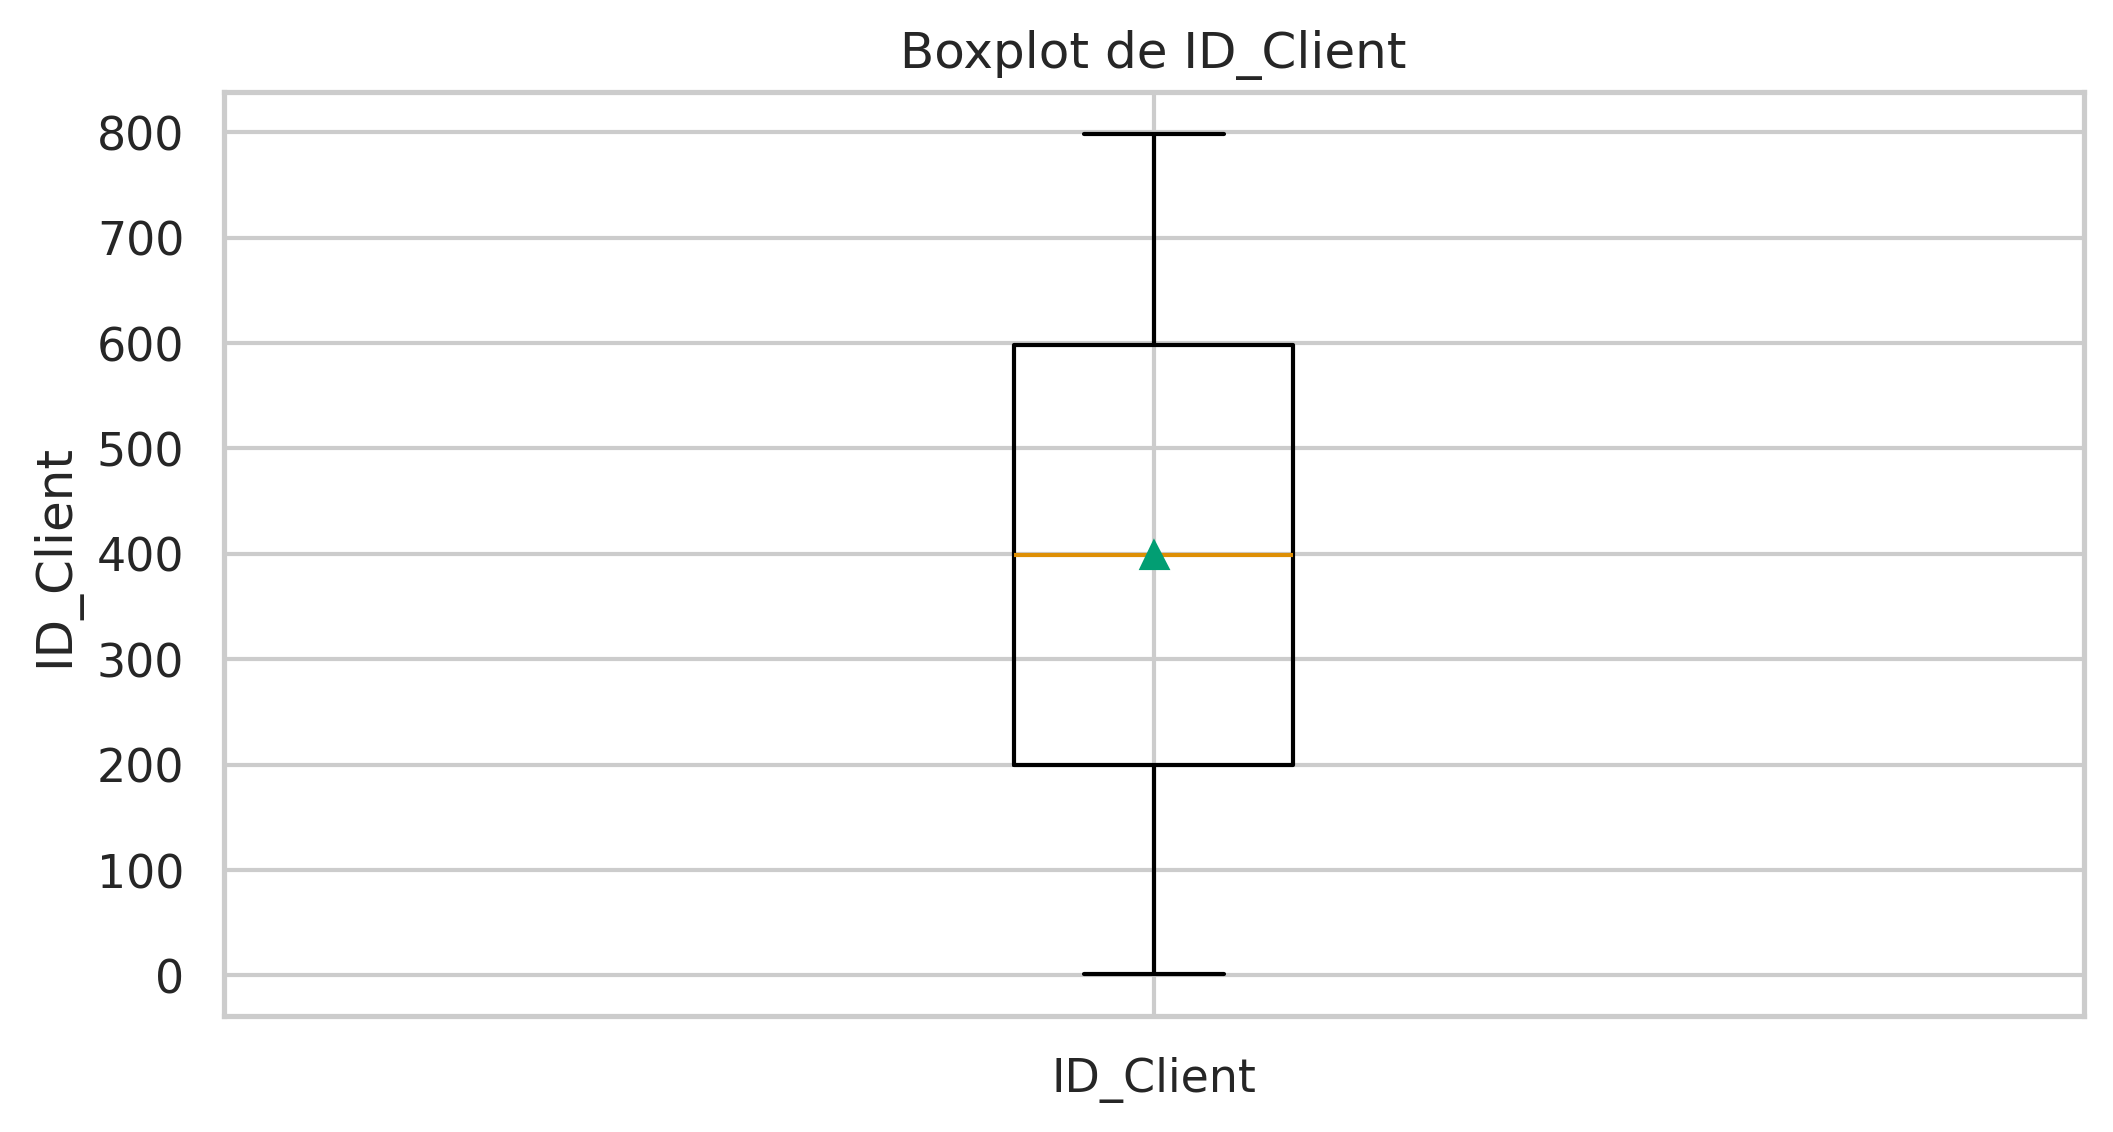

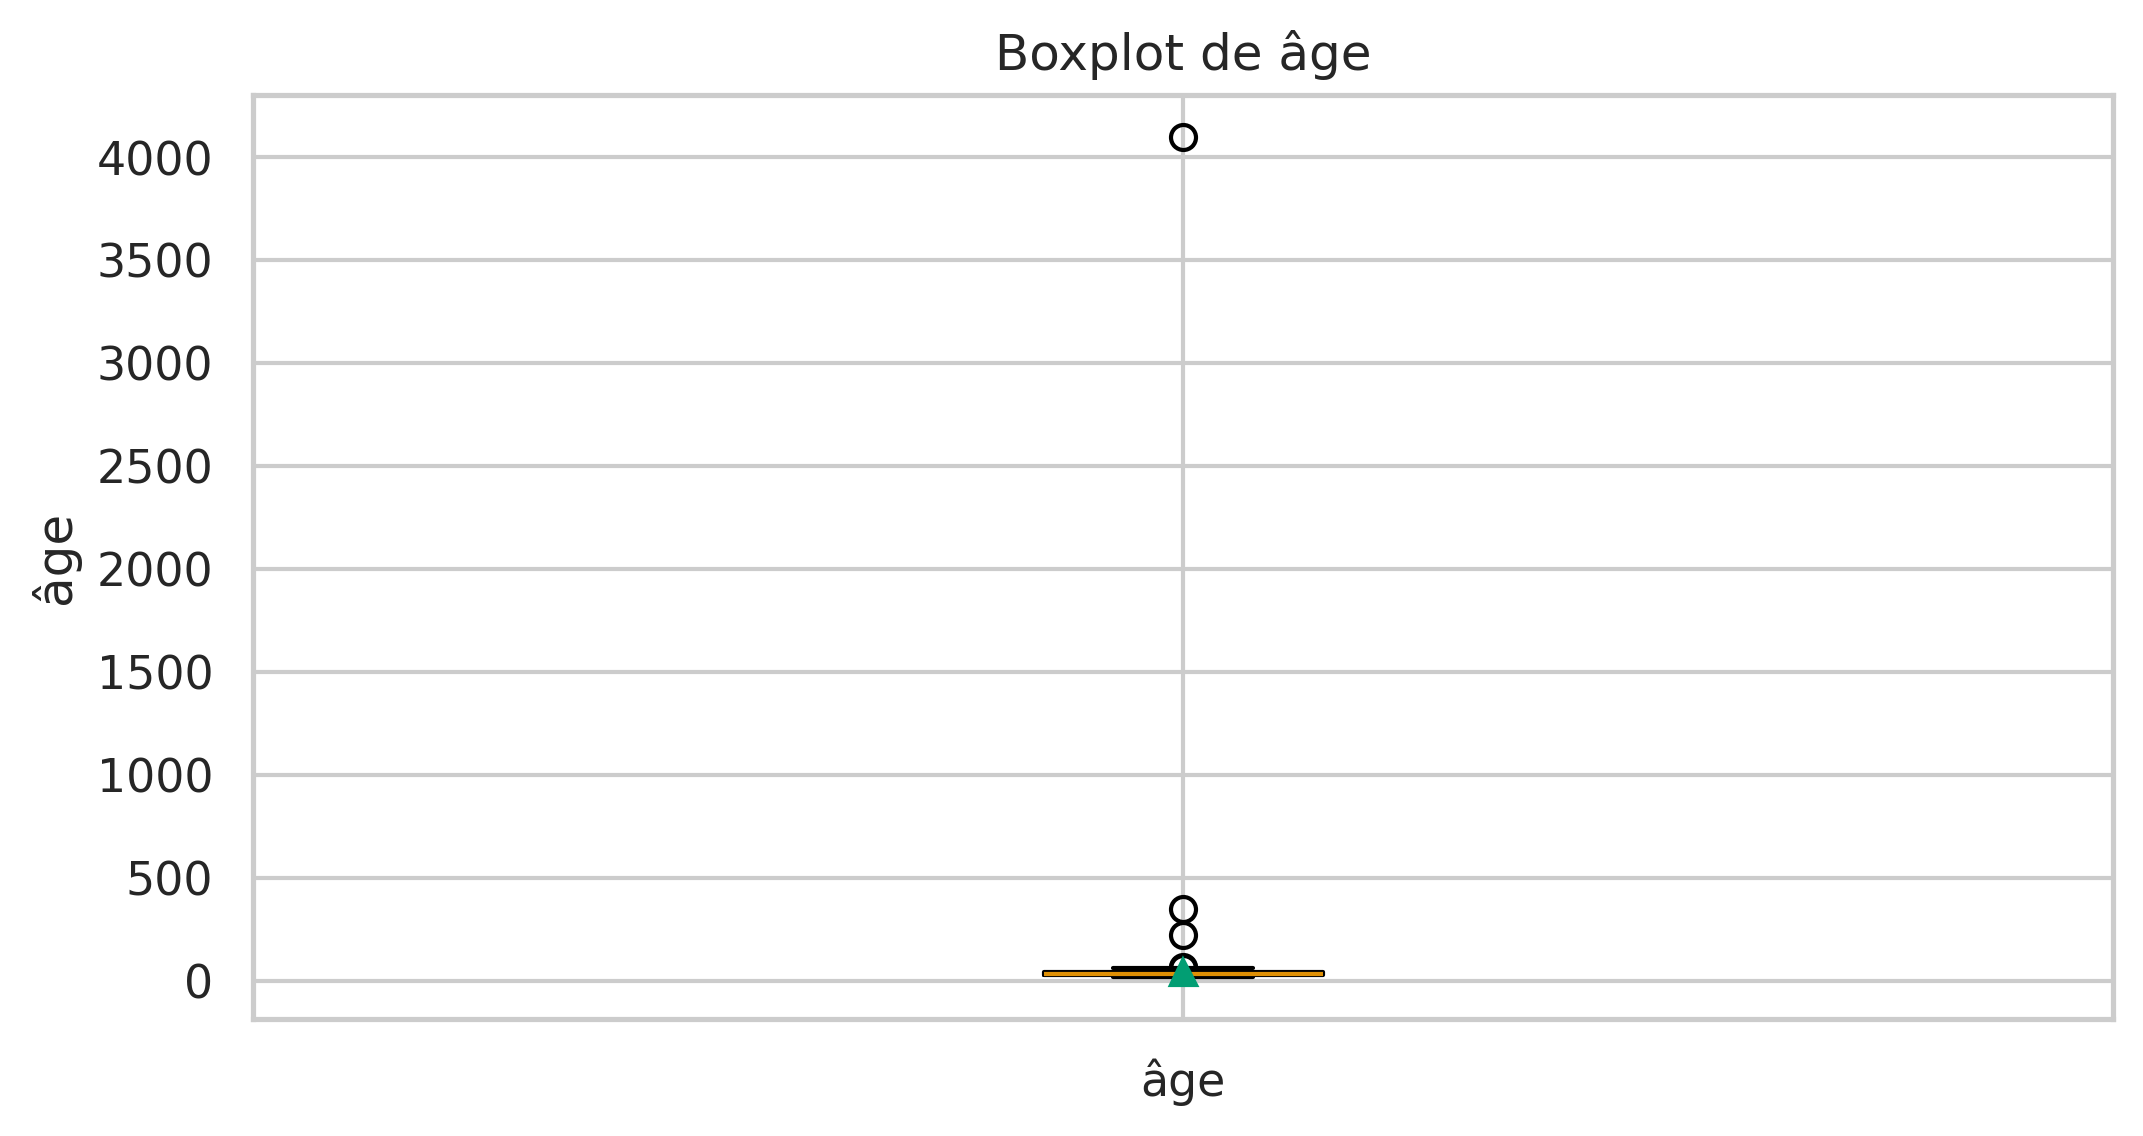

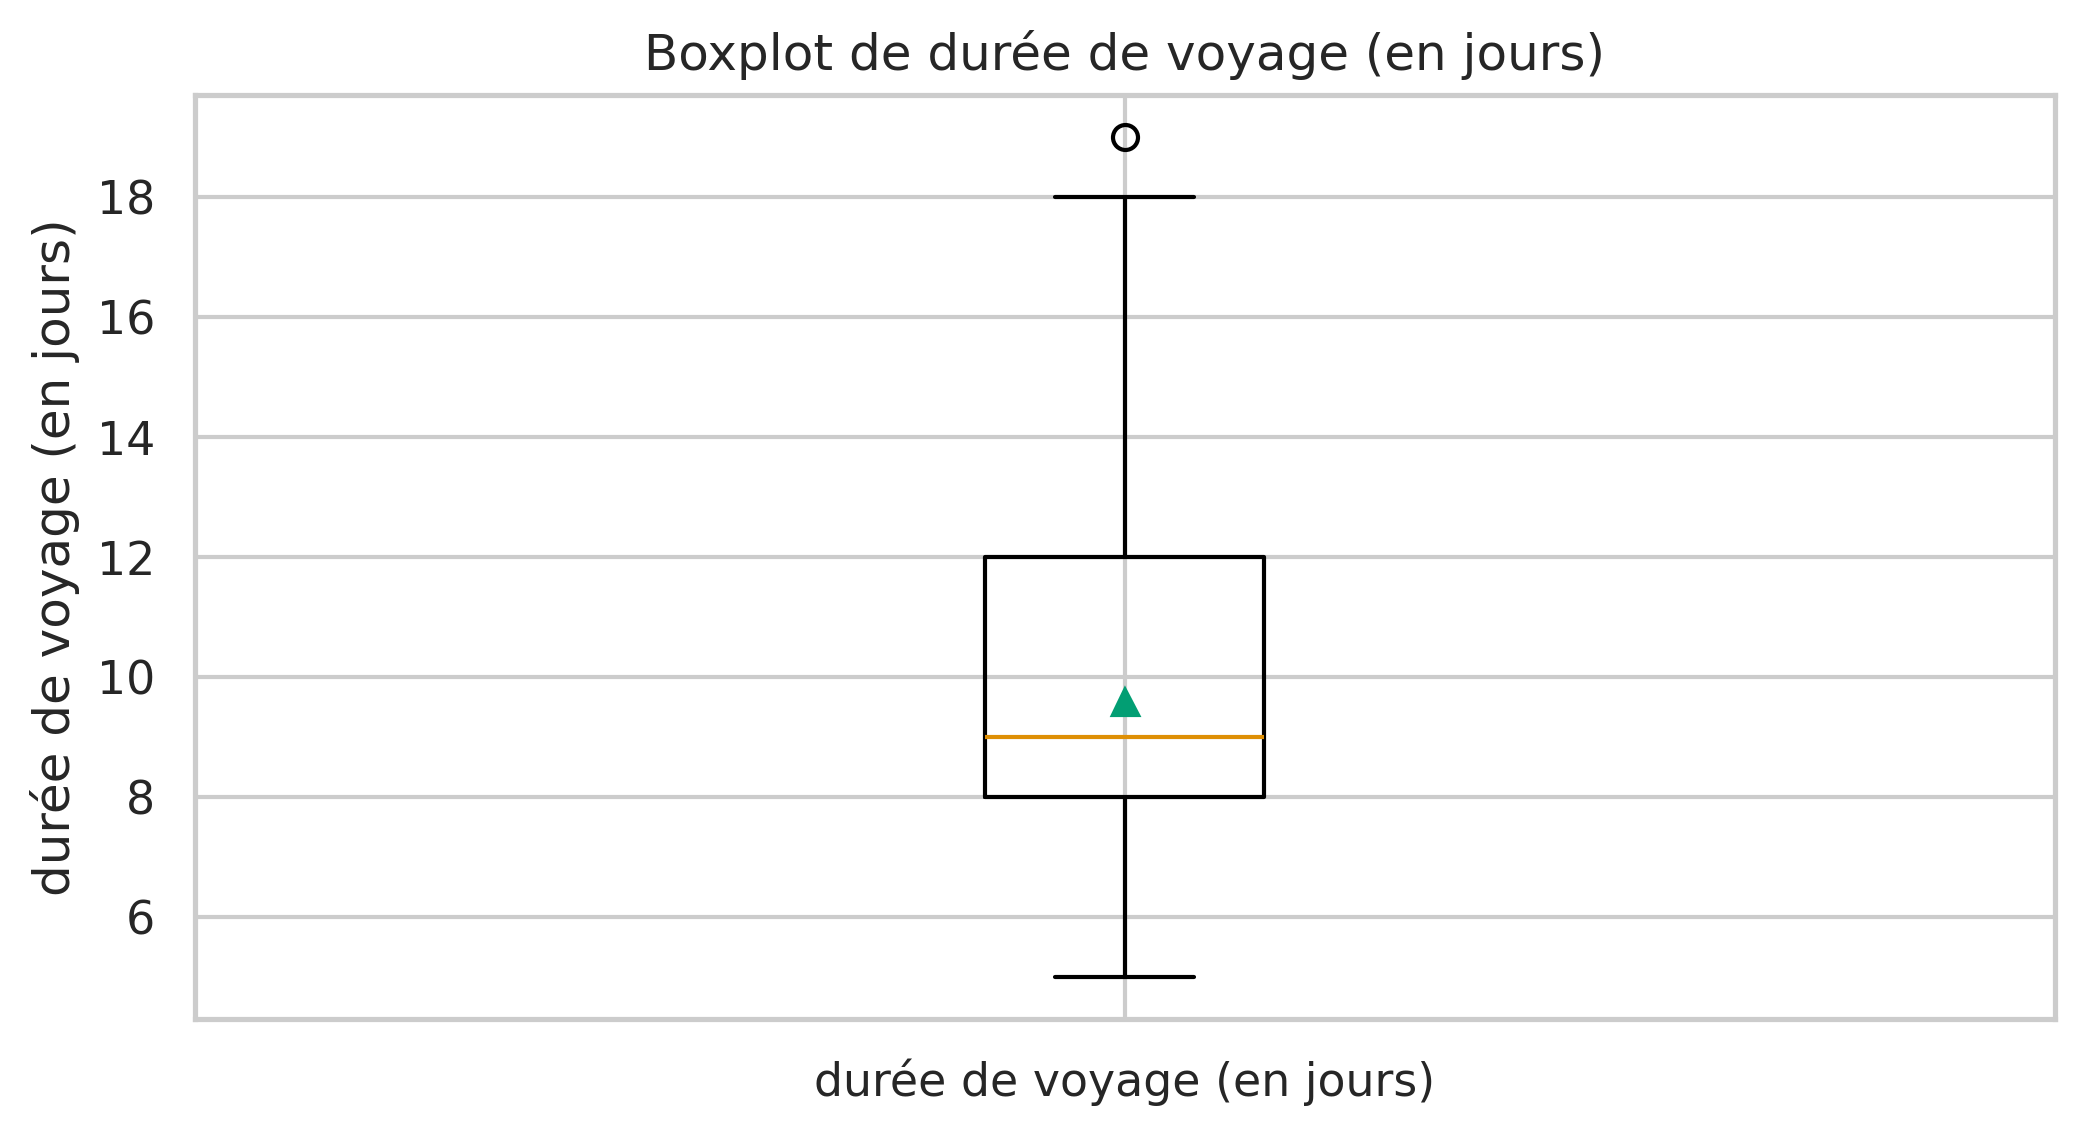

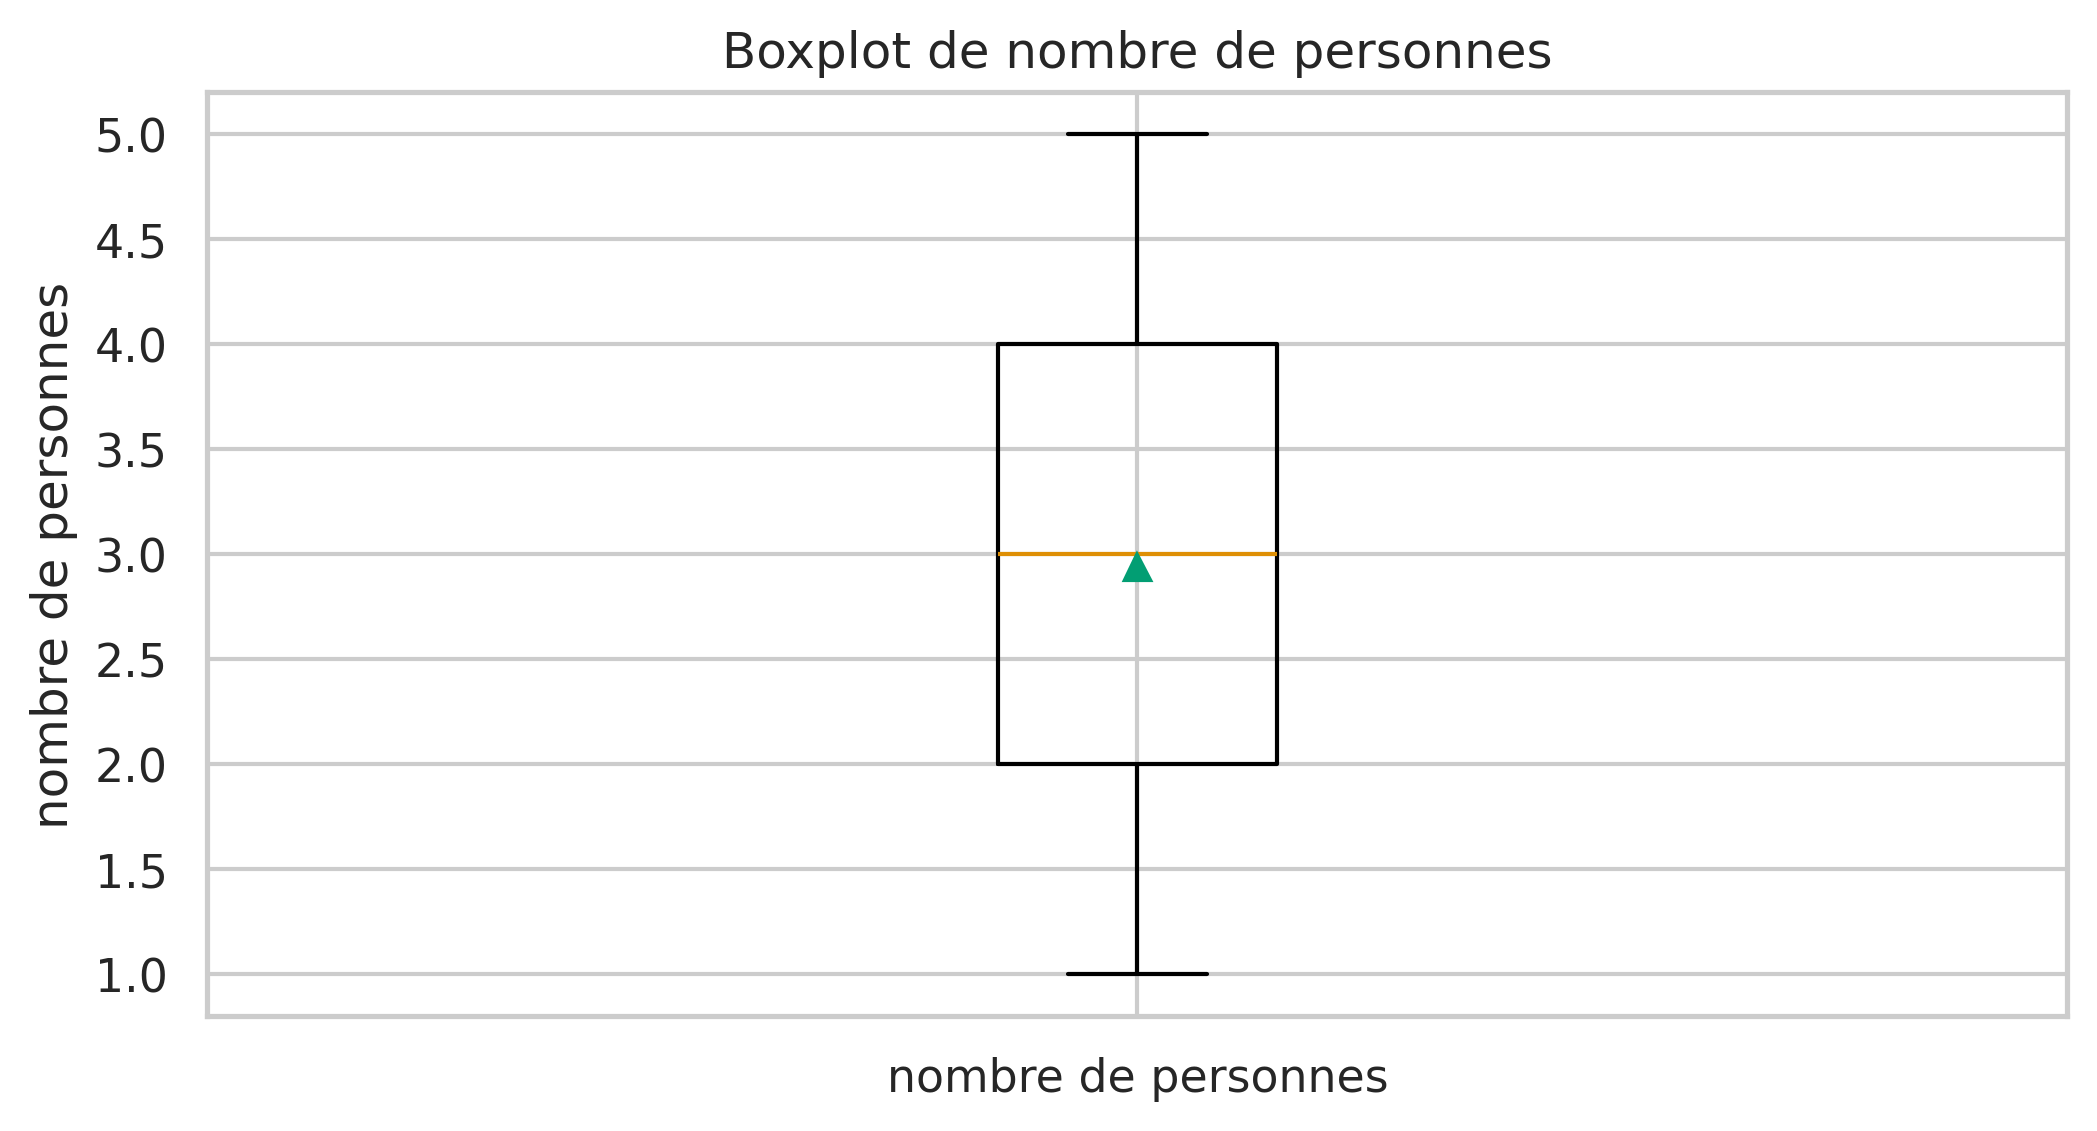

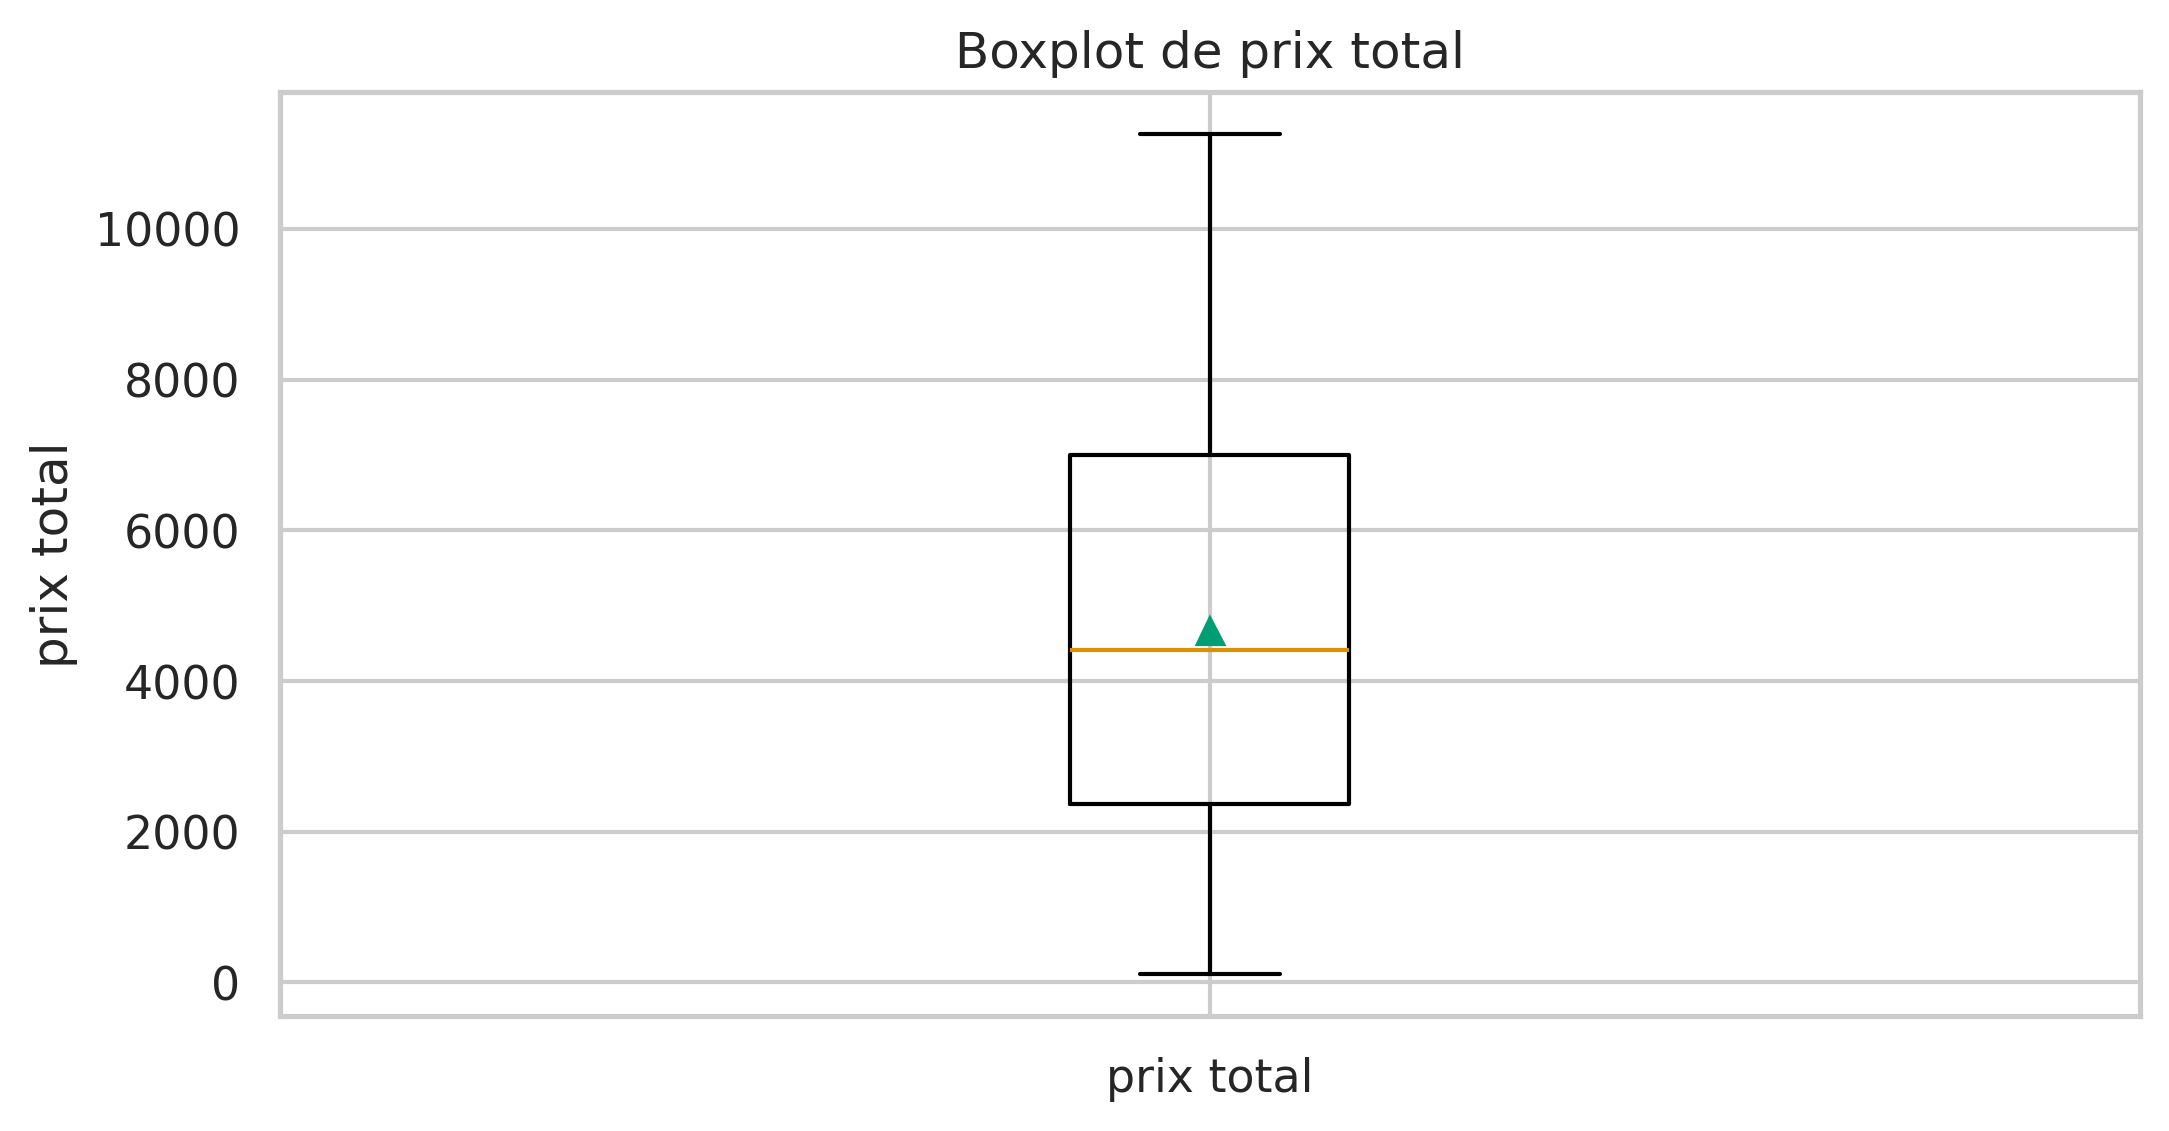

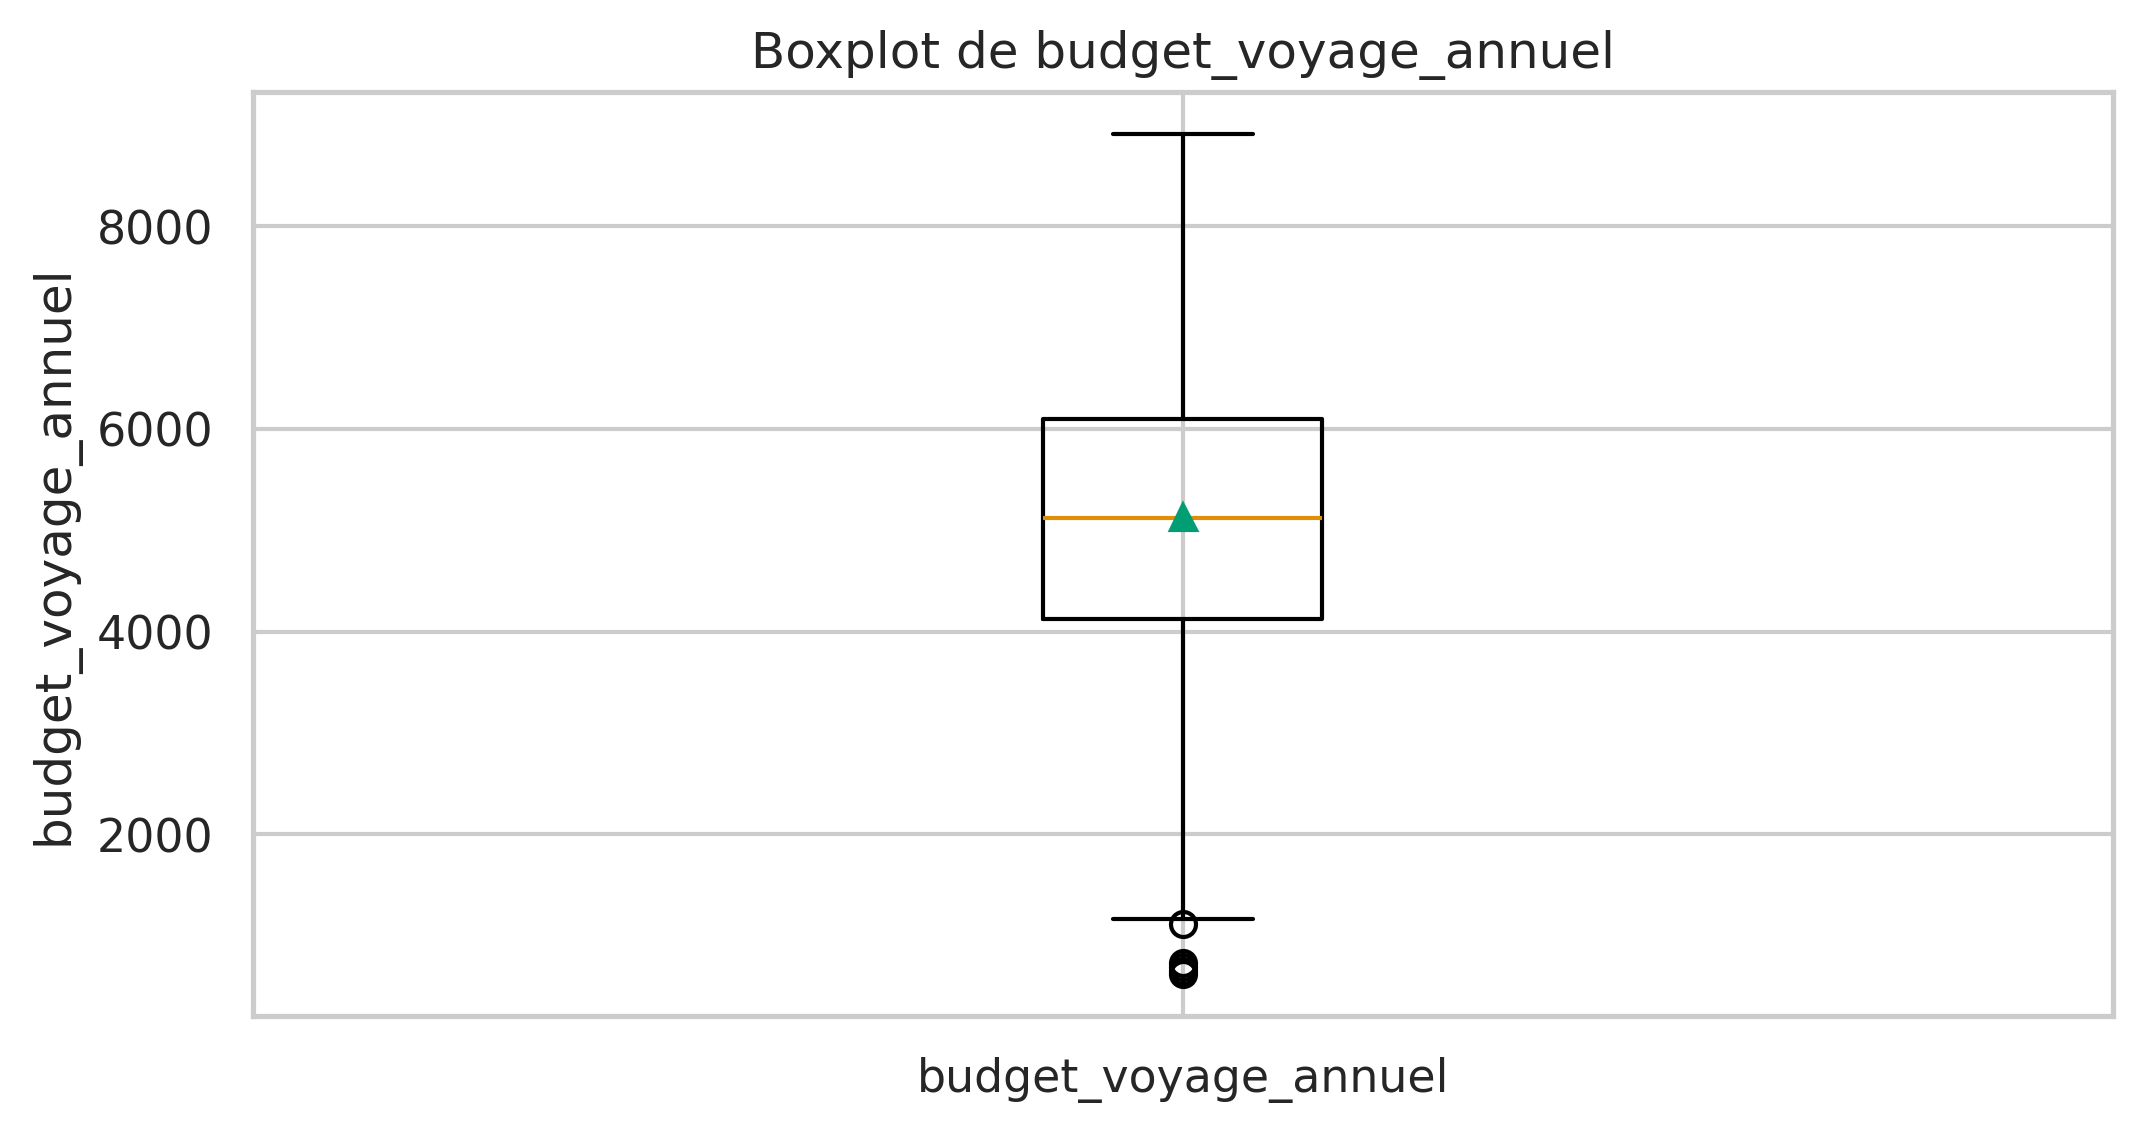

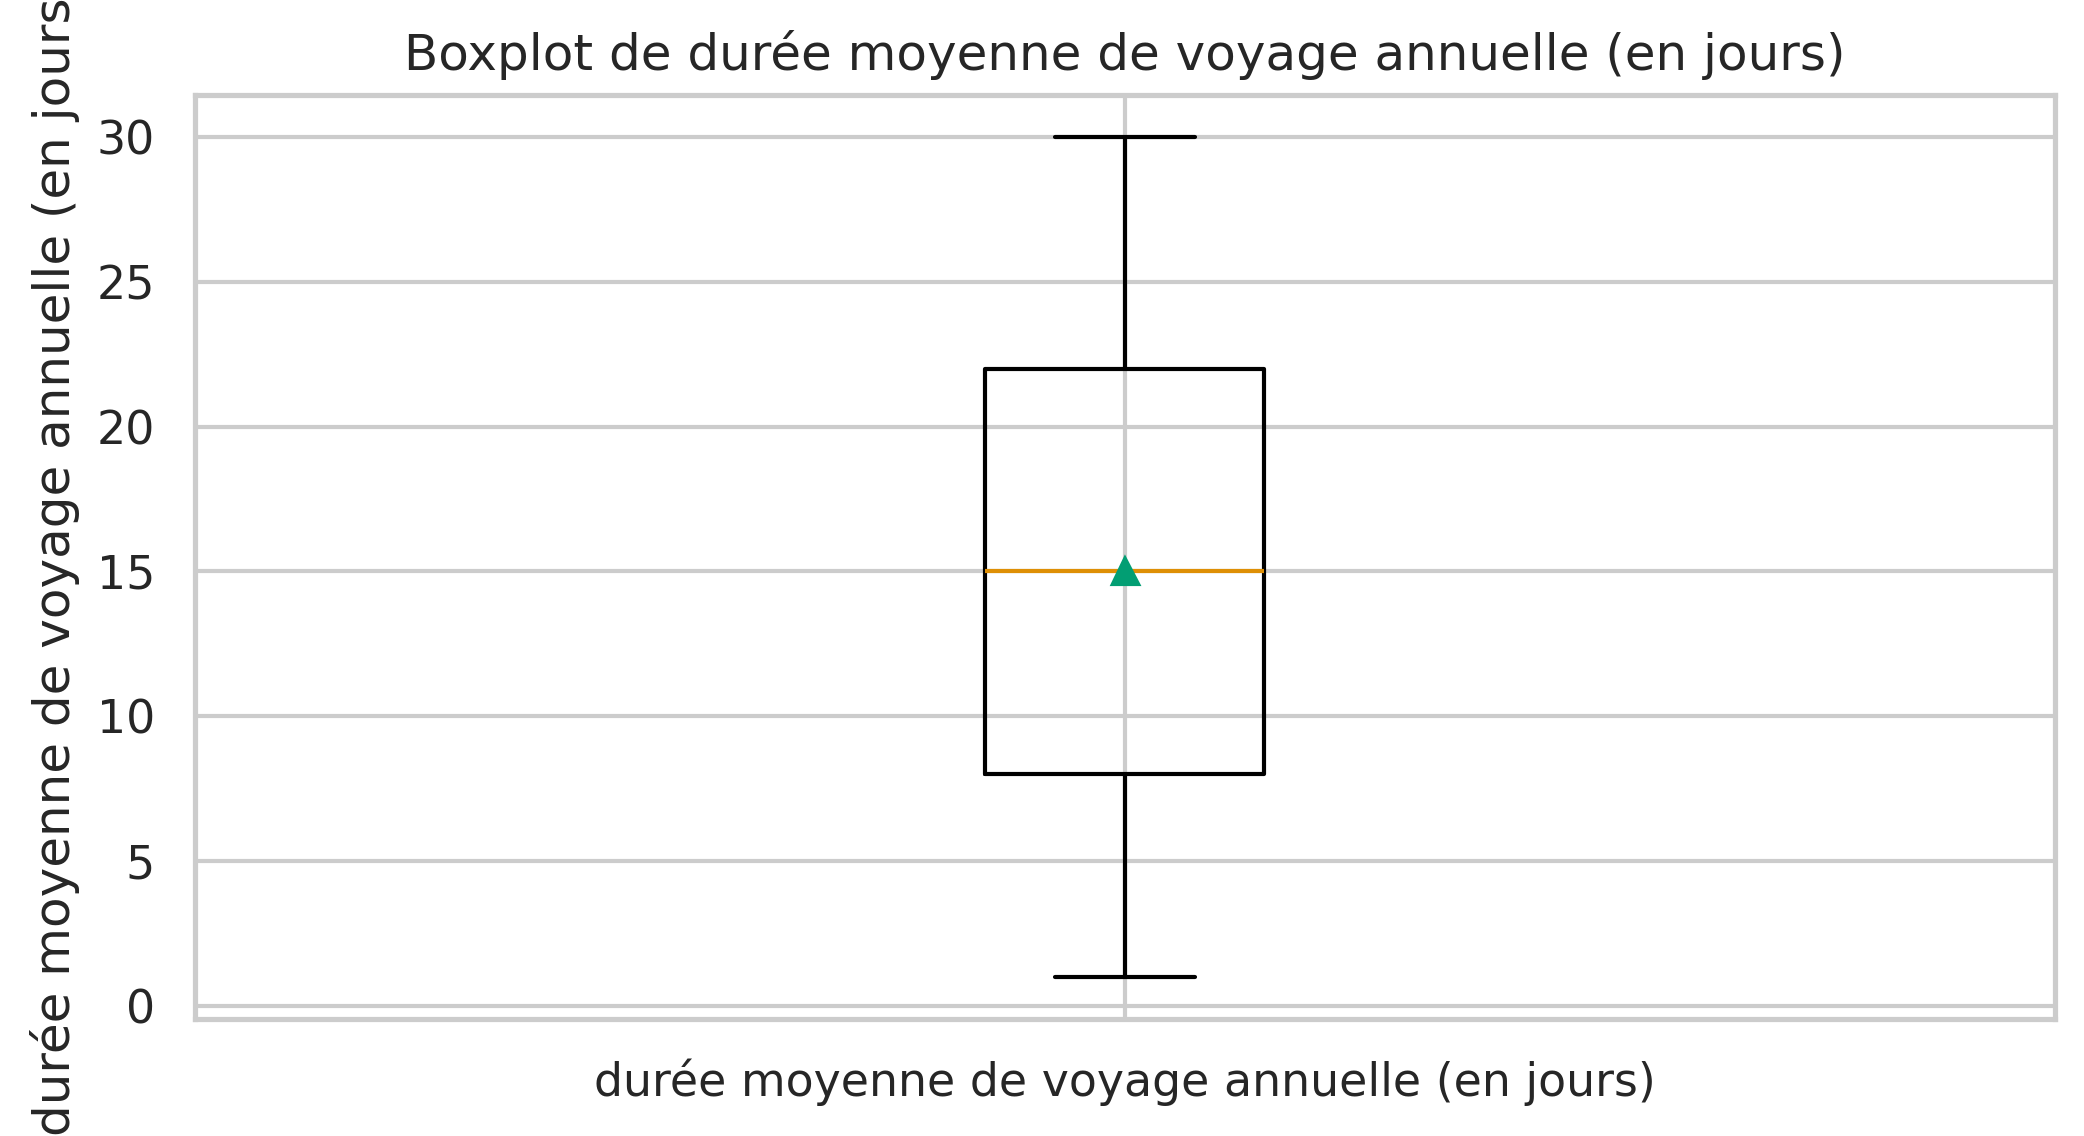

In [59]:
#Visualisation avec Box plot
import matplotlib.pyplot as plt

colonnes_num_client = data_client.select_dtypes(
    include=['int64', 'float64']
).columns

for col in colonnes_num_client:

    plt.figure(figsize=(8,4))

    plt.boxplot(
        data_client[col].dropna(),

        labels=[col],

        showmeans=True
    )

    plt.title(f'Boxplot de {col}')

    plt.ylabel(col)

    plt.grid(True)

    plt.show()

## Analyse des valeurs aberrantes avec les Boxplots

Afin d’identifier les valeurs aberrantes et de mieux comprendre la distribution des variables numériques, des boxplots ont été réalisés pour chaque colonne numérique du dataset.

Les boxplots permettent de visualiser plusieurs éléments statistiques importants :

- la médiane,
- la dispersion des données,
- les quartiles,
- les valeurs minimales et maximales normales,
- ainsi que les valeurs aberrantes (outliers).

### Interprétation des éléments du boxplot

#### 1. La boîte (Box)

La boîte représente les 50 % centraux des données :

- la limite inférieure correspond au premier quartile (Q1),
- la limite supérieure correspond au troisième quartile (Q3).

Cette zone contient donc la moitié des observations.

---

#### 2. La ligne orange

La ligne orange située à l’intérieur de la boîte représente la **médiane** des données (Q2).

La médiane correspond à la valeur qui sépare les données en deux parties égales :

- 50 % des valeurs sont inférieures,
- 50 % des valeurs sont supérieures.

La position de cette ligne permet également de détecter une éventuelle asymétrie dans la distribution.

---

#### 3. Le triangle vert

Le triangle vert représente la **moyenne** des données.

La moyenne et la médiane peuvent être comparées afin d’analyser la symétrie de la distribution :

- si la moyenne est proche de la médiane, la distribution est relativement équilibrée ;
- si elles sont éloignées, cela peut indiquer une asymétrie ou la présence de valeurs extrêmes.

---

#### 4. Les moustaches

Les lignes verticales appelées moustaches représentent l’étendue normale des données.

Elles sont calculées à partir de la règle de l’écart interquartile (IQR).

---

#### 5. Les points isolés

Les points situés en dehors des moustaches correspondent aux valeurs aberrantes (outliers).

Ces valeurs peuvent provenir :

- d’erreurs de saisie,
- de données atypiques,
- ou de cas exceptionnels.

Dans notre dataset, certaines valeurs aberrantes ont notamment été observées dans la variable âge, où des valeurs anormalement élevées ont été détectées.

---

### Conclusion

L’utilisation des boxplots a permis d’identifier rapidement les distributions des variables numériques ainsi que les valeurs atypiques présentes dans le dataset. Cette étape est essentielle pour garantir la qualité des données avant toute analyse statistique ou application de modèles de machine learning.

La présence d’une valeur aberrante extrême dans la variable âge (valeur supérieure à 4000) a fortement influencé l’échelle du boxplot ainsi que la moyenne statistique. Cette observation illustre l’impact important des outliers sur les mesures sensibles comme la moyenne. À l’inverse, la médiane reste beaucoup plus robuste face aux valeurs extrêmes, ce qui justifie son utilisation dans les analyses descriptives.

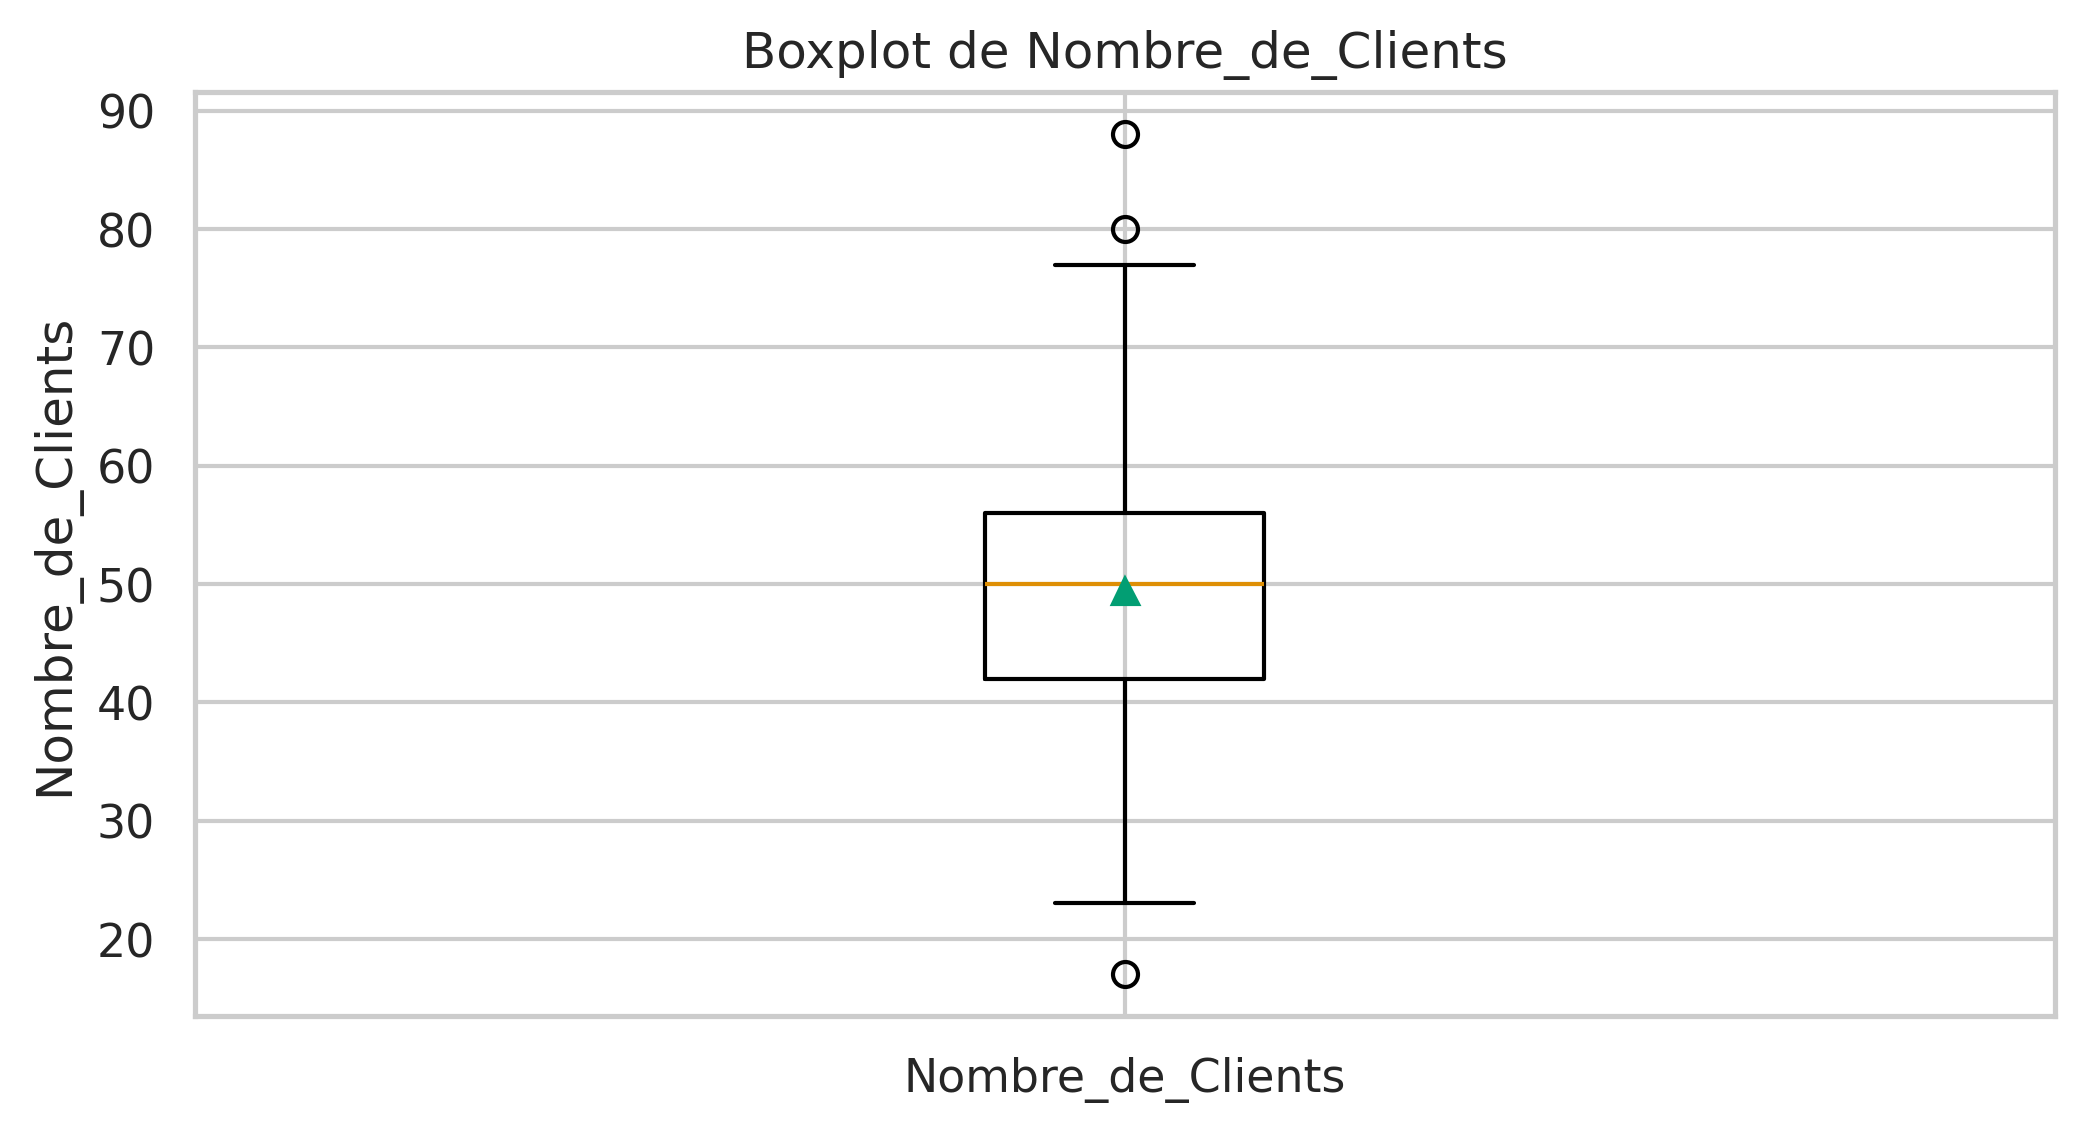

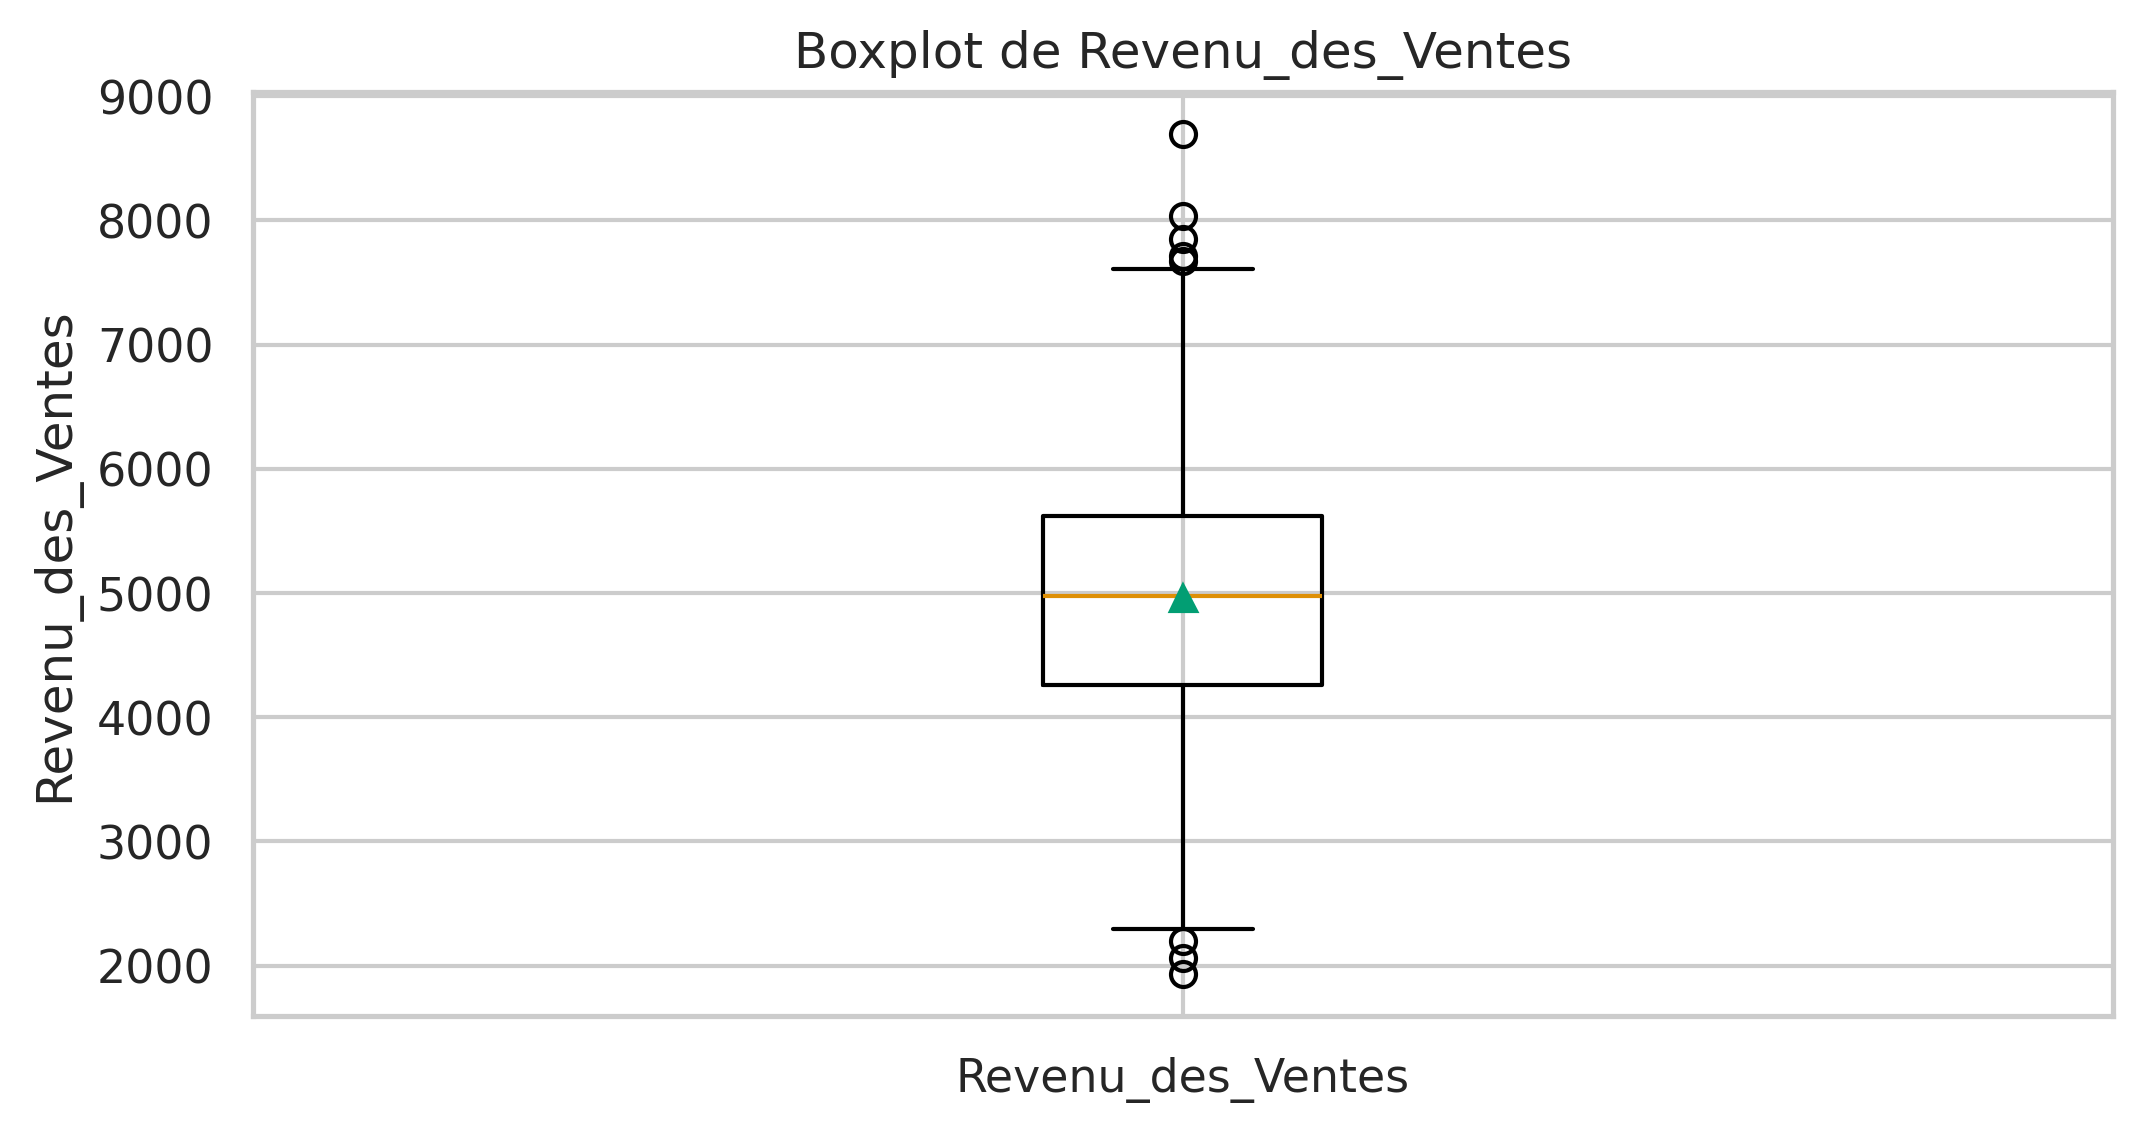

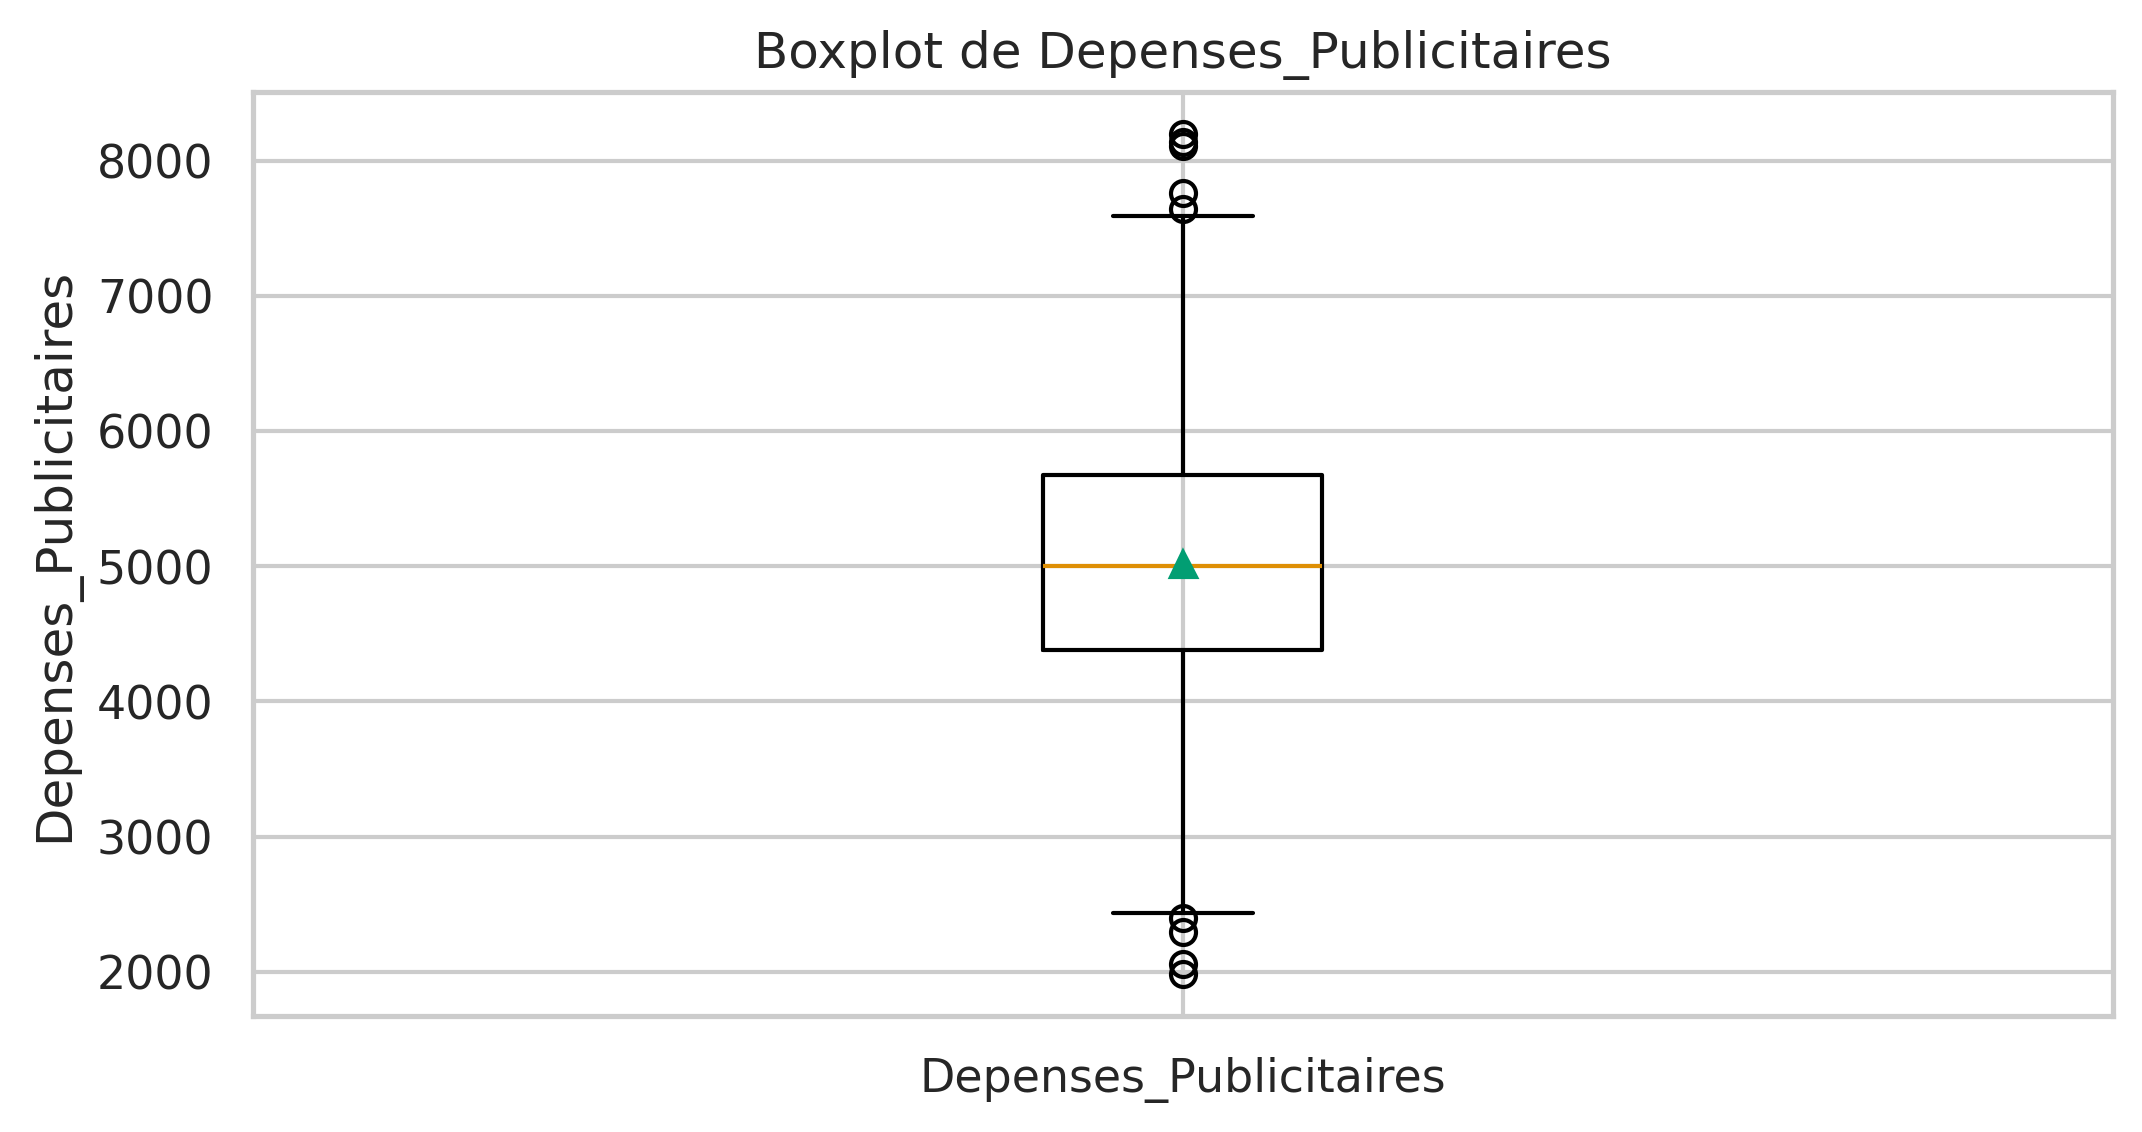

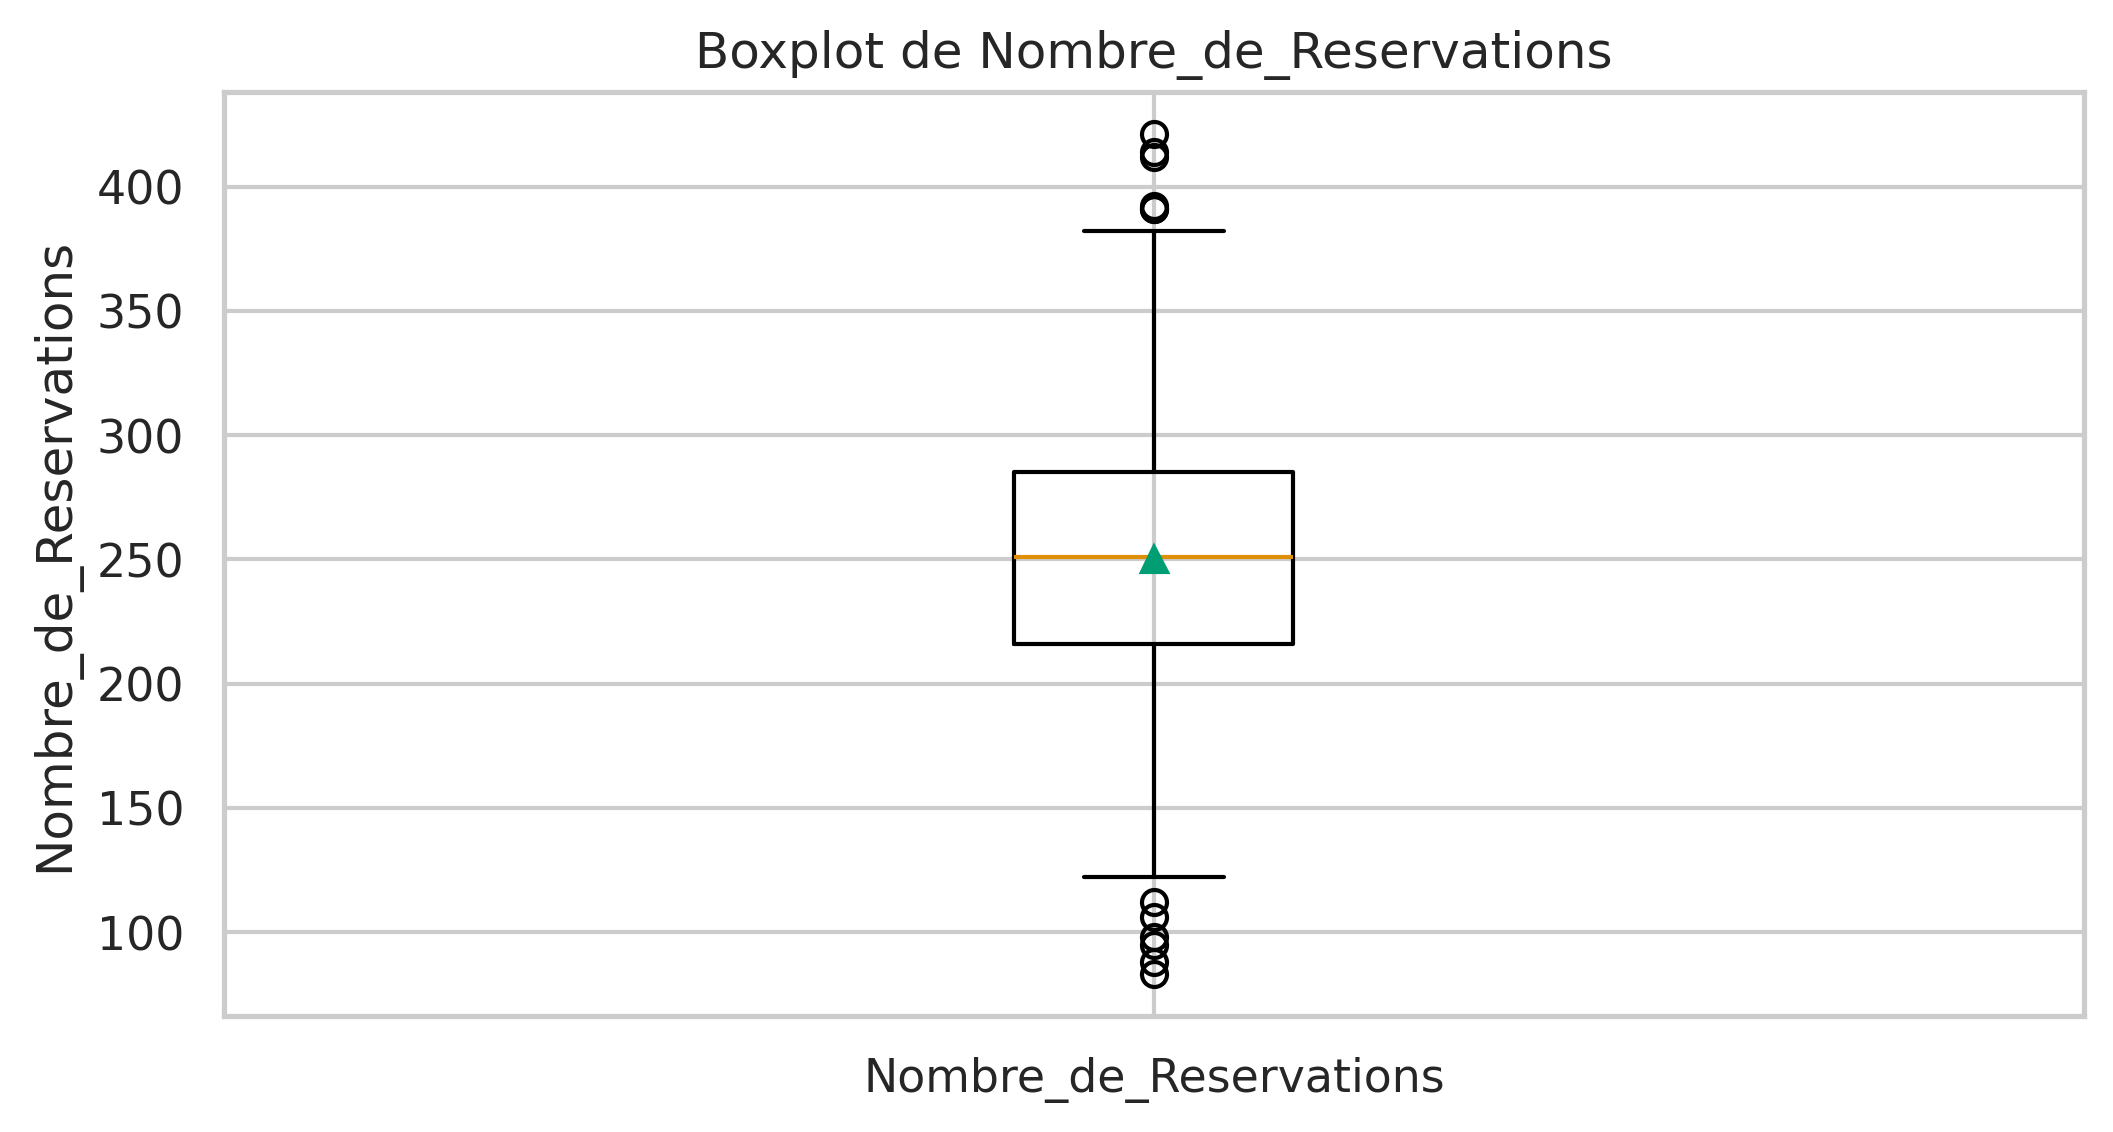

In [60]:
colonnes_num_entreprise = data_entreprise.select_dtypes(
    include=['int64', 'float64']
).columns

for col in colonnes_num_entreprise:

    plt.figure(figsize=(8,4))

    plt.boxplot(
        data_entreprise[col].dropna(),

        labels=[col],

        showmeans=True
    )

    plt.title(f'Boxplot de {col}')

    plt.ylabel(col)

    plt.grid(True)

    plt.show()

L’analyse des boxplots des variables numériques du dataset entreprise met en évidence la présence de quelques valeurs aberrantes (outliers) dans plusieurs variables.

Cependant, ces valeurs extrêmes ne semblent pas avoir un impact statistique majeur sur la distribution globale des données. En effet, les moyennes et les médianes restent relativement proches pour la plupart des variables, ce qui suggère une asymétrie faible des distributions.

Cette observation est également cohérente avec les coefficients d’asymétrie (skewness), dont les valeurs restent globalement proches de zéro. Les distributions peuvent donc être considérées comme relativement équilibrées malgré la présence de certains outliers.

**8.1 Analyse des valeurs extremes et aberrantes**

Affichage des outliers des différents dataset et analyse

In [61]:
colonnes_num_client = data_client.select_dtypes(
    include=['int64', 'float64']
).columns

for col in colonnes_num_client:

    Q1 = data_client[col].quantile(0.25)
    Q3 = data_client[col].quantile(0.75)

    IQR = Q3 - Q1

    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    outliers = data_client[
        (data_client[col] < borne_inf) |
        (data_client[col] > borne_sup)
    ]

    print(f"\n{col}")
    print("Nombre d'outliers :", len(outliers))
    print(outliers[col])


ID_Client
Nombre d'outliers : 0
Series([], Name: ID_Client, dtype: int64)

âge
Nombre d'outliers : 5
36      350
51      220
76     4100
120      64
284      63
Name: âge, dtype: int64

durée de voyage (en jours)
Nombre d'outliers : 1
793    19
Name: durée de voyage (en jours), dtype: int64

nombre de personnes
Nombre d'outliers : 0
Series([], Name: nombre de personnes, dtype: int64)

prix total
Nombre d'outliers : 0
Series([], Name: prix total, dtype: int64)

budget_voyage_annuel
Nombre d'outliers : 5
262     727
302     656
556    1113
740     692
792     618
Name: budget_voyage_annuel, dtype: int64

durée moyenne de voyage annuelle (en jours)
Nombre d'outliers : 0
Series([], Name: durée moyenne de voyage annuelle (en jours), dtype: float64)




*   Par rapport à l'âge, nous pouvons clairement supprimer les outliers dont la valeur est supérieure à 100
*   Concernant les autres variables notamment duree de voyage et budget annuel de voyage. On reisuqe perdre des information si on les supprime ou les impute. Nous allons les garder tels quel pour une bonne analyse future.



In [66]:
#Suppression des outliers absurdes de l'âge
data_client = data_client[
    (data_client['âge'] >= 0) &
    (data_client['âge'] <= 100)
]

In [65]:
colonnes_num_entreprise = data_entreprise.select_dtypes(
    include=['int64', 'float64']
).columns

for col in colonnes_num_entreprise:

    Q1 = data_entreprise[col].quantile(0.25)
    Q3 = data_entreprise[col].quantile(0.75)

    IQR = Q3 - Q1

    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    outliers = data_entreprise[
        (data_entreprise[col] < borne_inf) |
        (data_entreprise[col] > borne_sup)
    ]

    print(f"\n{col}")
    print("Nombre d'outliers :", len(outliers))
    print(outliers[col])


Nombre_de_Clients
Nombre d'outliers : 3
209    88
262    17
478    80
Name: Nombre_de_Clients, dtype: int64

Revenu_des_Ventes
Nombre d'outliers : 8
113    7715
179    7852
209    8693
262    1929
478    8038
646    2195
668    2061
755    7673
Name: Revenu_des_Ventes, dtype: int64

Depenses_Publicitaires
Nombre d'outliers : 9
15     8193
150    2296
334    7644
357    8137
371    2059
424    1980
435    7759
658    2395
705    8109
Name: Depenses_Publicitaires, dtype: int64

Nombre_de_Reservations
Nombre d'outliers : 12
15     414
150     83
311    391
324    392
334    421
357    391
371     88
424     98
466    112
584    106
658     95
705    412
Name: Nombre_de_Reservations, dtype: int64


Pour ce dataset entreprise, nous jugeons que les outliers dans les categories numériques sont nécessaires pour une bonne anlyse future.

### **9. Dates et heures : format et cohérence**


In [67]:
#Vérification des types
print(
    data_client[
        [
            'date de début de voyage',
            'date de fin de voyage'
        ]
    ].dtypes
)

date de début de voyage    datetime64[ns]
date de fin de voyage      datetime64[ns]
dtype: object


In [68]:
#Vérifions la cohérence des dates
#Date fin < date début
dates_incoherentes = data_client[
    data_client['date de fin de voyage']
    <
    data_client['date de début de voyage']
]

print(dates_incoherentes)

Empty DataFrame
Columns: [ID_Client, âge, genre, type de voyage, destination, saison de voyage, durée de voyage (en jours), nombre de personnes, prix total, mode de paiement, évaluation sur 5, date de début de voyage, date de fin de voyage, période de voyage, budget_voyage_annuel, durée moyenne de voyage annuelle (en jours)]
Index: []


In [70]:
#Vérifions la cohérence de la durée
#Calcul
duree_calculee = (
    data_client['date de fin de voyage']
    -
    data_client['date de début de voyage']
).dt.days

#Durée
comparaison = data_client[
    duree_calculee !=
    data_client['durée de voyage (en jours)']
]

print(comparaison)


     ID_Client  âge  genre type de voyage destination saison de voyage  \
0            1   32      M       Culturel        Bali              été   
1            2   38  Autre        détente       Népal        printemps   
2            3   39  Autre        détente     Norvège            hiver   
3            4   49  Autre       Aventure       Japon        printemps   
4            5   23      M       Aventure     Islande              été   
..         ...  ...    ...            ...         ...              ...   
796        794   43      M        Détente        Bali        printemps   
797        795   39      F       Aventure     Vietnam            hiver   
798        796   25  Autre        Détente      Brésil            hiver   
799        797   24  Autre       aventure     Islande            hiver   
800        798   46  Autre       Culturel      France              été   

     durée de voyage (en jours)  nombre de personnes  prix total  \
0                            10            

Les colonnes temporelles ont été converties avec succès au format datetime. Les vérifications de cohérence montrent que les dates de fin de voyage sont globalement postérieures aux dates de début.

Cependant les durées de voyage calculées à partir des dates ne sont pas cohérentes avec les durées enregistrées dans le dataset.



In [ ]:
data_client['durée de voyage réelle'] = (
    data_client['date de fin de voyage']
    -
    data_client['date de début de voyage']
).dt.days

La vérification de cohérence entre les dates de début et de fin de voyage et la variable « durée de voyage (en jours) » a révélé un grand nombre d’incohérences dans le dataset.

En recalculant la durée réelle à partir des dates, la majorité des observations présentaient des différences significatives avec les durées enregistrées dans la colonne initiale. Cette situation suggère que les variables temporelles ont probablement été générées indépendamment ou ne correspondent pas à la même définition métier.

Afin de garantir la cohérence analytique des données, une nouvelle variable de durée calculée à partir des dates a été créée et privilégiée pour les analyses ultérieures.

---
Aussi dans le cadre de ces dates, nous jugens que dans le datset_client, la colone periode de voyage n'apporte aucune information supplémentaire. Nous pouvons donc la supprimer sans perdre aucune information ou diminuer la précisiion de notre analyse.


In [72]:
data_client = data_client.drop(
    columns=['période de voyage']
)

### **10. Granularité des données attendue**
Ici nous allons étudier le niveau de détail d'une ligne

In [73]:
voyages_par_client = data_client[
    'ID_Client'
].value_counts()

print(voyages_par_client)

ID_Client
110    3
16     2
527    1
528    1
529    1
      ..
275    1
276    1
277    1
278    1
266    1
Name: count, Length: 793, dtype: int64


In [74]:
print(
    "Clients uniques :",
    data_client['ID_Client'].nunique()
)

print(
    "Nombre total lignes :",
    len(data_client)
)

Clients uniques : 793
Nombre total lignes : 796


On voit qu'un client peut éffectuer plusieurs voyages. Nous avons précisement un voyageur qui a éffectué 3 voyages et un autre qui en a éffectué 2. Le niveau de granularité retenu est donc le voyage individuel.

# Phase 4 : Analyse Exploratoire des Données (EDA)

## But :
L'objectif de cette phase est d'explorer les données de manière approfondie pour identifier des tendances, des patterns et des insights significatifs.

+ Nature des questions à se poser pour guider l'analyse exploratoire :
1. Quelle est la distrubution des différentes variables quantitatives ?
2. Quelle est la répartition des différentes variables catégorielles ?
3. Comparaison entre les varibales Quanti x Quali ?
4. Y a-t-il des différences significatives entre les groupes de données (par exemple, par sexe, âge, etc.) ?
5. Y a-t-il des corrélations entre les différentes variables ?
6. Comment les différentes variables évoluent-elles dans le temps (si applicable) ?
7. y a-t-il des valeurs aberrantes ou des points de données qui pourraient influencer les résultats de l'analyse ( Anomalie )?

+ Sortir des insights pertinents et les transformer en questions précises et actionnables pour la suite de l'analyse ( brouillon avec bp de graphiques rapides).


# Phase 5 : Insights Principaux

## But :
3-6 Questions précises et actionnables.

# Phase 6 : Visualisations Explicatives

## But :
3-6 visualisations graphiques exportées avec une bonne qualité, faciles à lire, avec des titres assertifs, tout en évitant les biais visuels et en respectant les principes d’éthique, afin de répondre à la question principale et 5 sous questions, accompagnées d’une explication de ce que chaque visualisation montre, d’une interprétation et d’une réponse claire aux questions.



# Phase 7 :  Recommandations & Conclusion

## But :
Formuler des recommandations basées sur les insights obtenus pour chaque questions et conclure l'analyse en résumant les principales découvertes et en suggérant des actions concrètes pour TripSky.

![image.png](attachment:image.png)